# Calibration diagnostics

Per-session per-cell T_sys distributions. Run `scan_load.ipynb` first
(it writes `scan_load_state.pkl` with `tsys_by_session_cell`).

In [1]:
import pickle
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

STATE_PATH = Path('artifacts/scan_load_state.pkl')
with open(STATE_PATH, 'rb') as f:
    state = pickle.load(f)

tsys_by_session_cell = state['tsys_by_session_cell']
sessions = state['sessions']
T_CAL = state.get('T_CAL_11', 79.0)

tsys_per_session = defaultdict(list)
for (sess, gl, gb), tsys in tsys_by_session_cell.items():
    tsys_per_session[sess].append(tsys)

all_tsys = np.array([t for ts in tsys_per_session.values() for t in ts])
print(f'Loaded {len(tsys_by_session_cell)} (session, cell) T_sys entries '
      f'across {len(tsys_per_session)} sessions')
print(f'Global: median={np.median(all_tsys):.1f} K, '
      f'range=[{all_tsys.min():.0f}, {all_tsys.max():.0f}] K')

Loaded 342 (session, cell) T_sys entries across 2 sessions
Global: median=210.0 K, range=[136, 395] K


In [2]:
import glob
import random
from collections import defaultdict
from pathlib import Path

N_PER_SESSION = 5


def _parse_coord(s):
    return float(s.replace('p', '.'))


cells_per_session = defaultdict(set)
for data_dir in ('data/main', 'data/nps'):
    for obs in sorted(glob.glob(f'{data_dir}/session_*/obs_*')):
        sess = f'{Path(obs).parent.parent.name}/{Path(obs).parent.name}'
        parts = Path(obs).name.split('_')
        try:
            gl, gb = _parse_coord(parts[1]), _parse_coord(parts[2])
        except (IndexError, ValueError):
            continue
        cells_per_session[sess].add((gl, gb))

if not cells_per_session:
    print('No obs cells found under data/main or data/nps.')
else:
    for sess in sorted(cells_per_session):
        cells = sorted(cells_per_session[sess])
        sample = random.sample(cells, min(N_PER_SESSION, len(cells)))
        sample_str = ', '.join(f'(l={l:g}, b={b:g})' for l, b in sample)
        print(f'{sess}  [{len(cells)} cells]  -> {sample_str}')

main/session_001  [197 cells]  -> (l=126, b=-2), (l=97.88, b=6), (l=98, b=0), (l=100, b=0), (l=95.99, b=2)
main/session_002  [145 cells]  -> (l=174.13, b=4), (l=158.21, b=6), (l=190.39, b=6), (l=192.18, b=4), (l=186, b=0)


/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


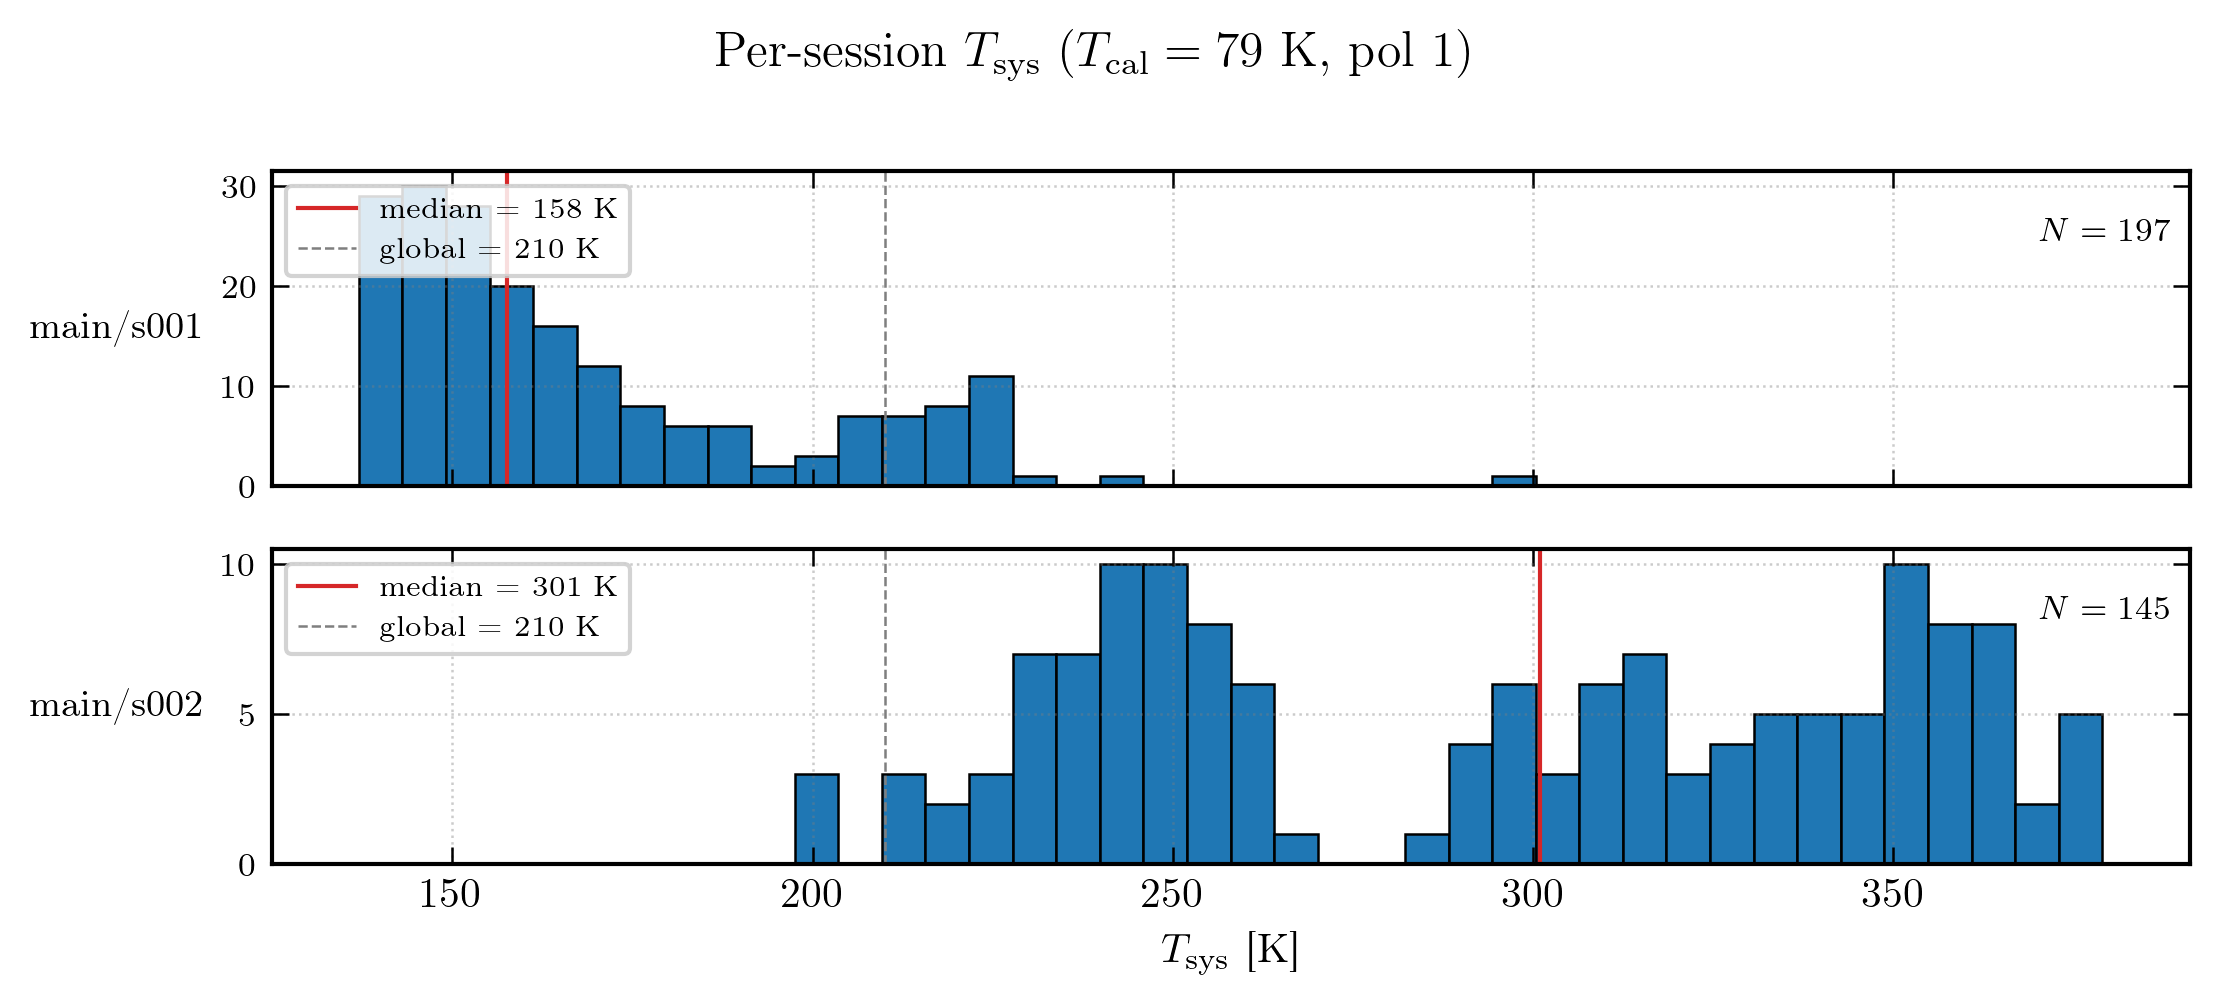

In [3]:
from plotters import plot_tsys_histograms_per_session

fig, _ = plot_tsys_histograms_per_session(tsys_per_session, T_cal=T_CAL)
plt.show()

## T_sys vs local time per session

For each session, plot per-cell `T_sys` against the mean local time
(America/Los_Angeles) of that cell's obs dumps. Reveals drifts within a
session (receiver warmup, daytime spillover, sky-temp variation as
sources move across the beam).

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


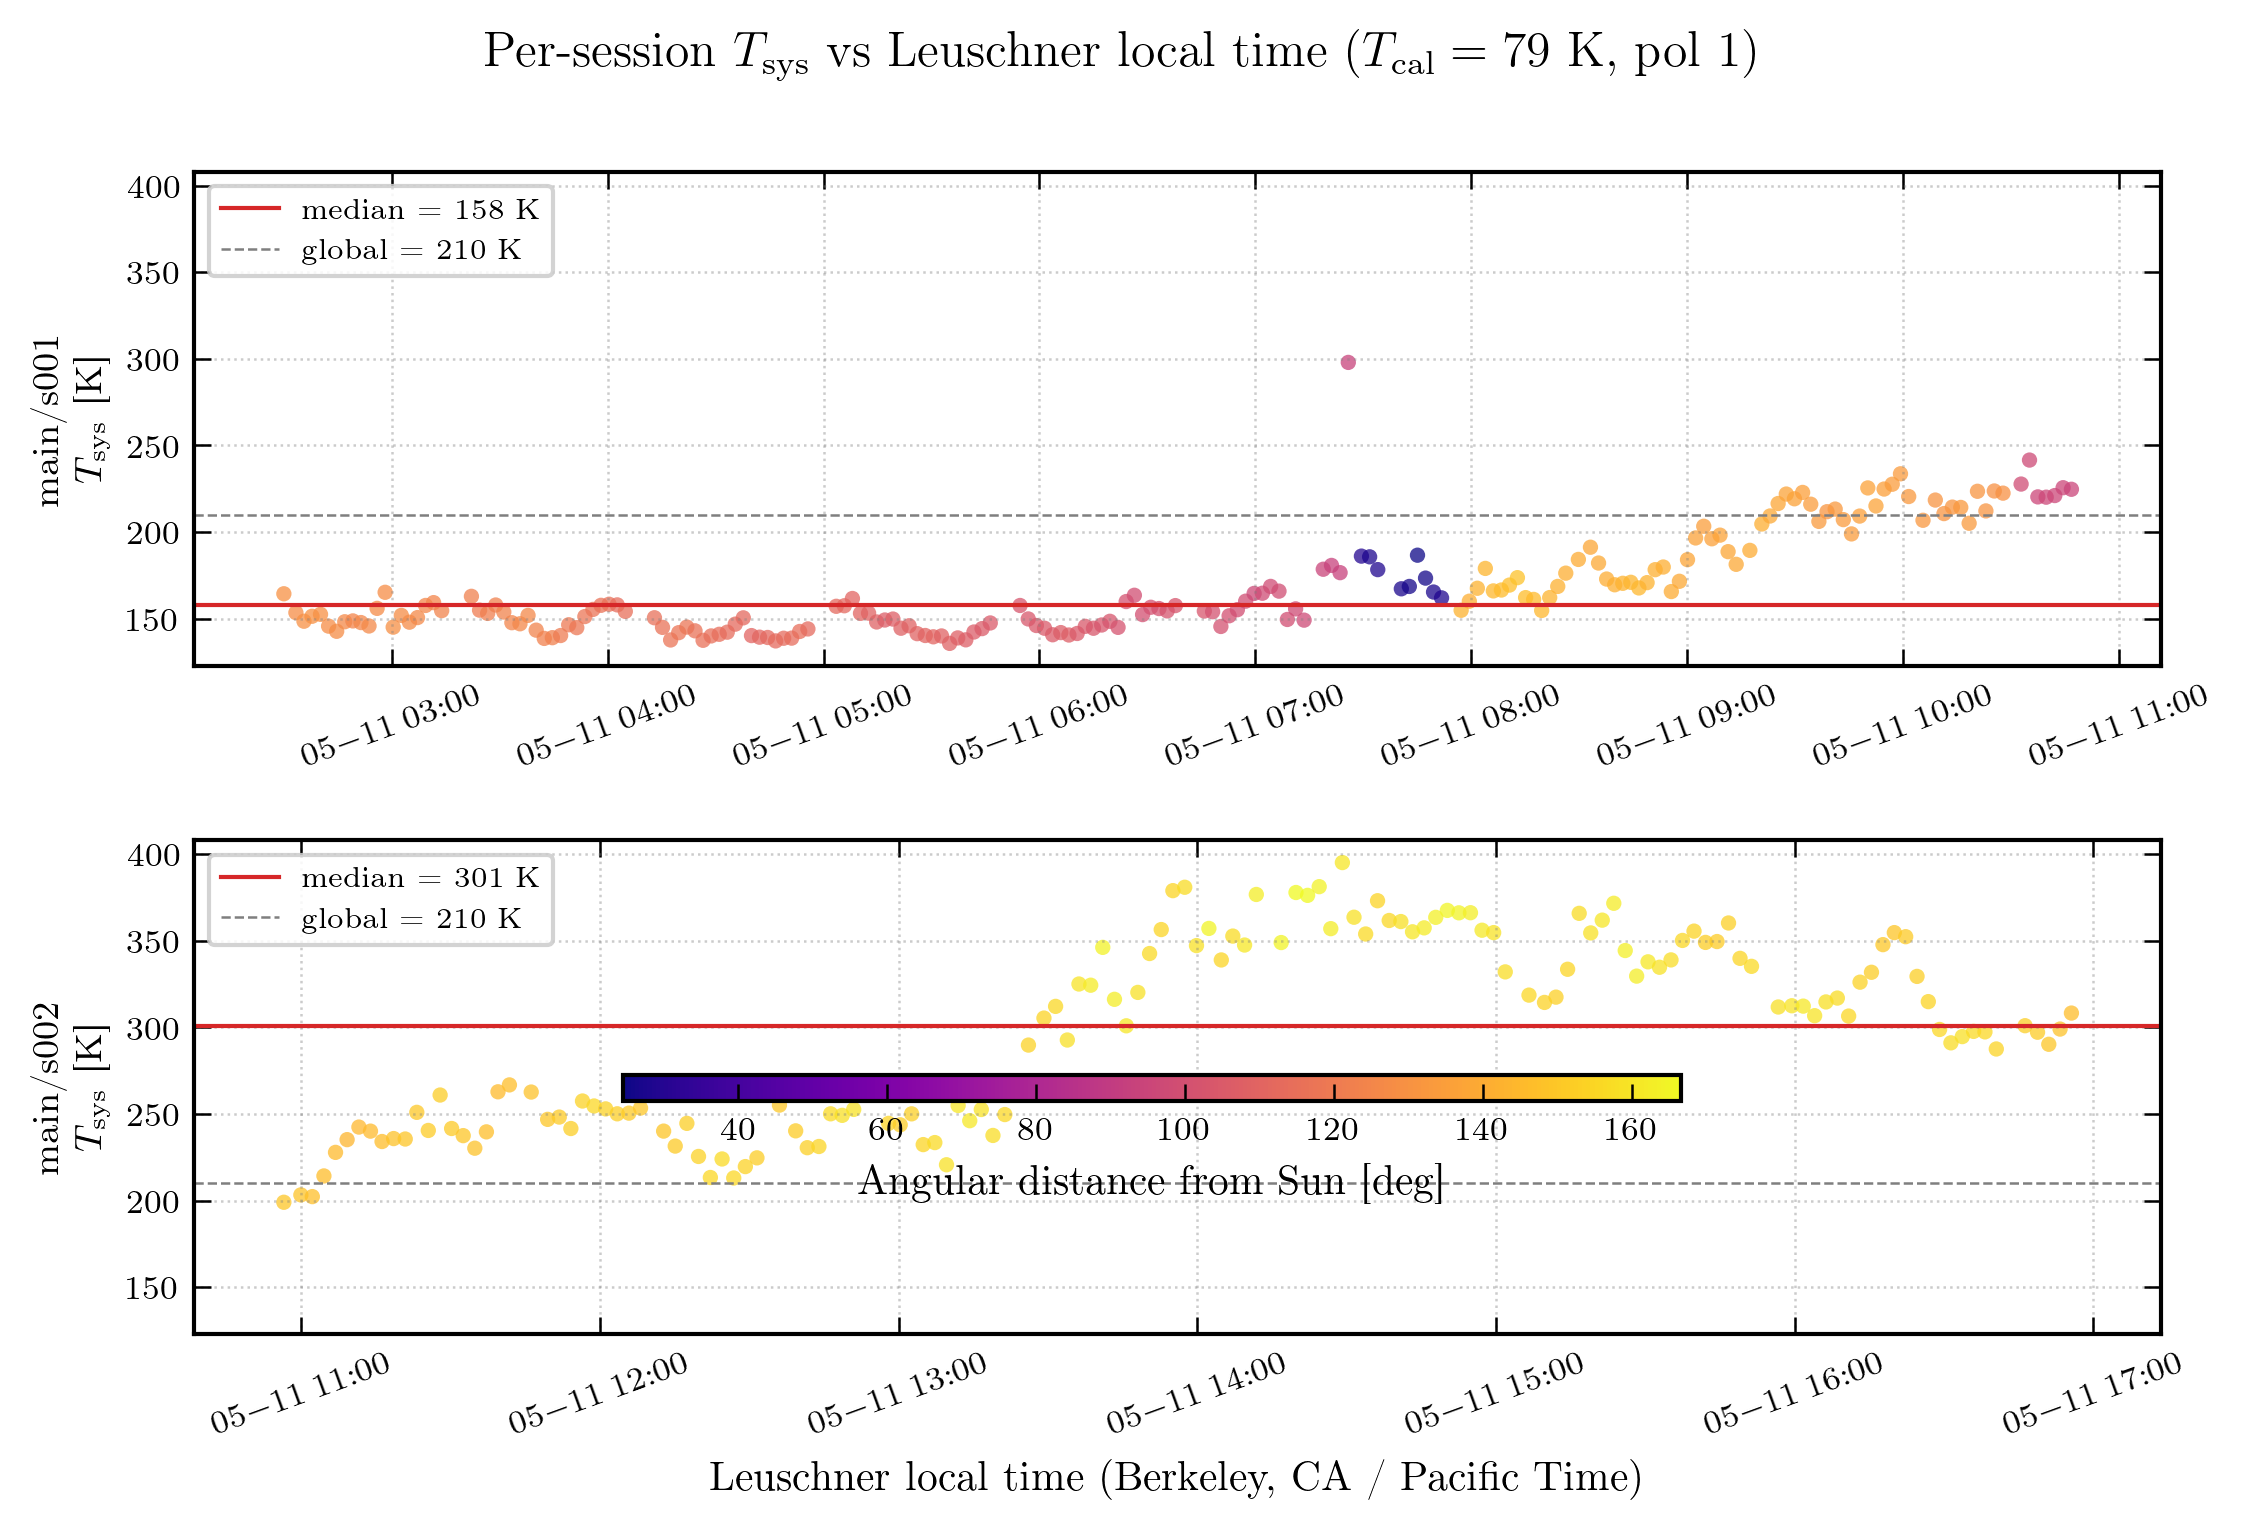

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


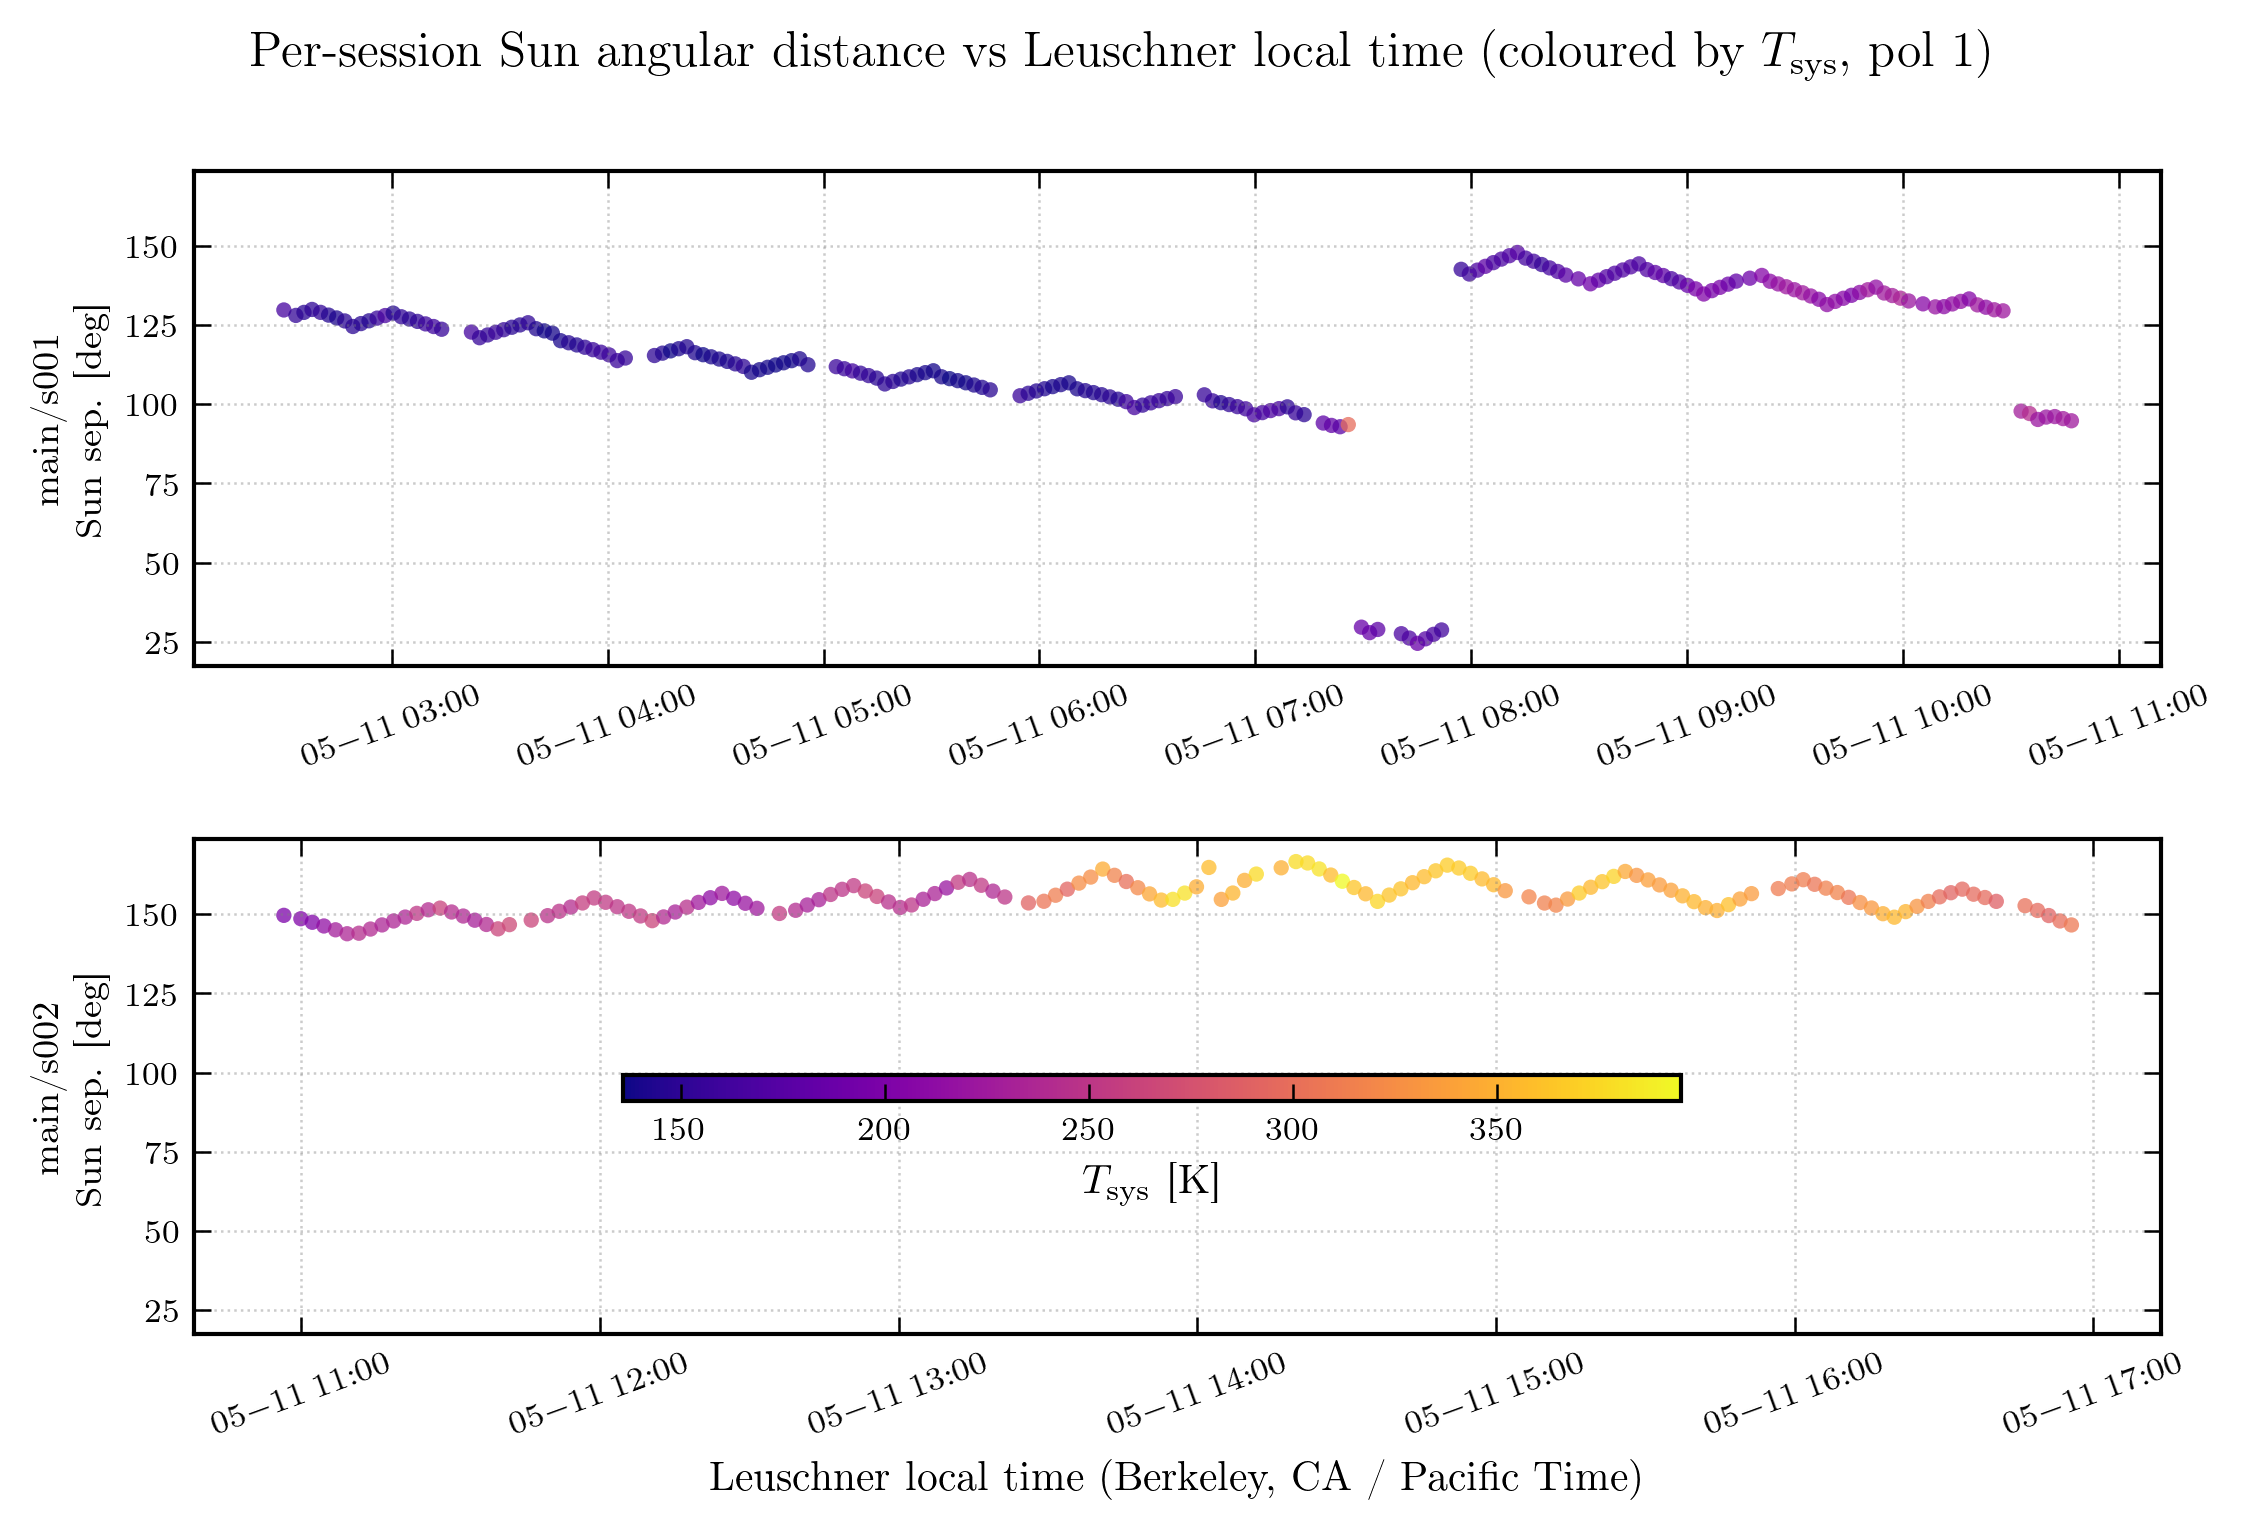

In [4]:
import glob
import datetime as _dt
import warnings
from collections import defaultdict
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy.units as u
from astropy.coordinates import SkyCoord, get_sun
from astropy.coordinates.baseframe import NonRotationTransformationWarning
from astropy.time import Time

from plotters import (
    plot_tsys_vs_local_time_per_session,
    plot_sun_sep_vs_local_time_per_session,
)

# Leuschner Observatory (Berkeley, CA) -- civil timezone is PT.
LEO_TZ = ZoneInfo('America/Los_Angeles')


def _parse_coord(s):
    return float(s.replace('p', '.'))


# Mean obs timestamp per (session, gl, gb).
ts_by_session_cell = defaultdict(list)
for data_dir in ('data/main', 'data/nps'):
    for npz in sorted(glob.glob(f'{data_dir}/session_*/obs_*/*.npz')):
        p = Path(npz)
        sess = f'{p.parent.parent.parent.name}/{p.parent.parent.name}'
        parts = p.parent.name.split('_')
        try:
            gl, gb = _parse_coord(parts[1]), _parse_coord(parts[2])
        except (IndexError, ValueError):
            continue
        try:
            with np.load(npz, allow_pickle=False) as f:
                ts_by_session_cell[(sess, gl, gb)].append(float(f['time']))
        except (OSError, KeyError, ValueError):
            continue


# Collect cells with timestamps, then batch the Sun lookup so the
# GCRS->Galactic transform runs once. The (expected)
# NonRotationTransformationWarning is suppressed -- the few-arcsec
# geocentric-vs-heliocentric ambiguity is negligible at our
# degree-level angular separations.
sess_keys, sess_tsys, sess_t_unix, sess_gl, sess_gb = [], [], [], [], []
n_missing = 0
for sess in sessions:
    if not tsys_per_session.get(sess):
        continue
    for (s, gl, gb), tsys in tsys_by_session_cell.items():
        if s != sess:
            continue
        ts_list = ts_by_session_cell.get((sess, gl, gb))
        if not ts_list:
            n_missing += 1
            continue
        sess_keys.append(sess)
        sess_tsys.append(tsys)
        sess_t_unix.append(float(np.mean(ts_list)))
        sess_gl.append(gl)
        sess_gb.append(gb)

points_per_session = {}
if sess_keys:
    times = Time(np.asarray(sess_t_unix), format='unix')
    pointings = SkyCoord(l=np.asarray(sess_gl) * u.deg,
                         b=np.asarray(sess_gb) * u.deg,
                         frame='galactic')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', NonRotationTransformationWarning)
        suns_gal = get_sun(times).transform_to('galactic')
        sun_seps_deg = pointings.separation(suns_gal).deg

    grouped = defaultdict(lambda: ([], [], []))
    for sess, tsys, t_unix, sep in zip(sess_keys, sess_tsys, sess_t_unix, sun_seps_deg):
        t_local = _dt.datetime.fromtimestamp(t_unix, LEO_TZ)
        grouped[sess][0].append(t_local)
        grouped[sess][1].append(tsys)
        grouped[sess][2].append(float(sep))
    points_per_session = dict(grouped)

if n_missing:
    print(f'{n_missing} (session, cell) entries had no matching npz timestamps')

fig, _ = plot_tsys_vs_local_time_per_session(
    points_per_session, T_cal=T_CAL, tz=LEO_TZ,
)
plt.show()

fig, _ = plot_sun_sep_vs_local_time_per_session(
    points_per_session, tz=LEO_TZ,
)
plt.show()

## Random pointing: cal vs obs spectra

For one randomly chosen cell, plot raw cal (dotted) and the three obs dumps (solid)
overlaid for each (LO, polarisation) combination -- 2 columns x 2 rows.


Session: main/session_001, cell: 136p01_2
  obs dumps: 6, cal dumps: 4, LOs: [1419.86, 1421.14]


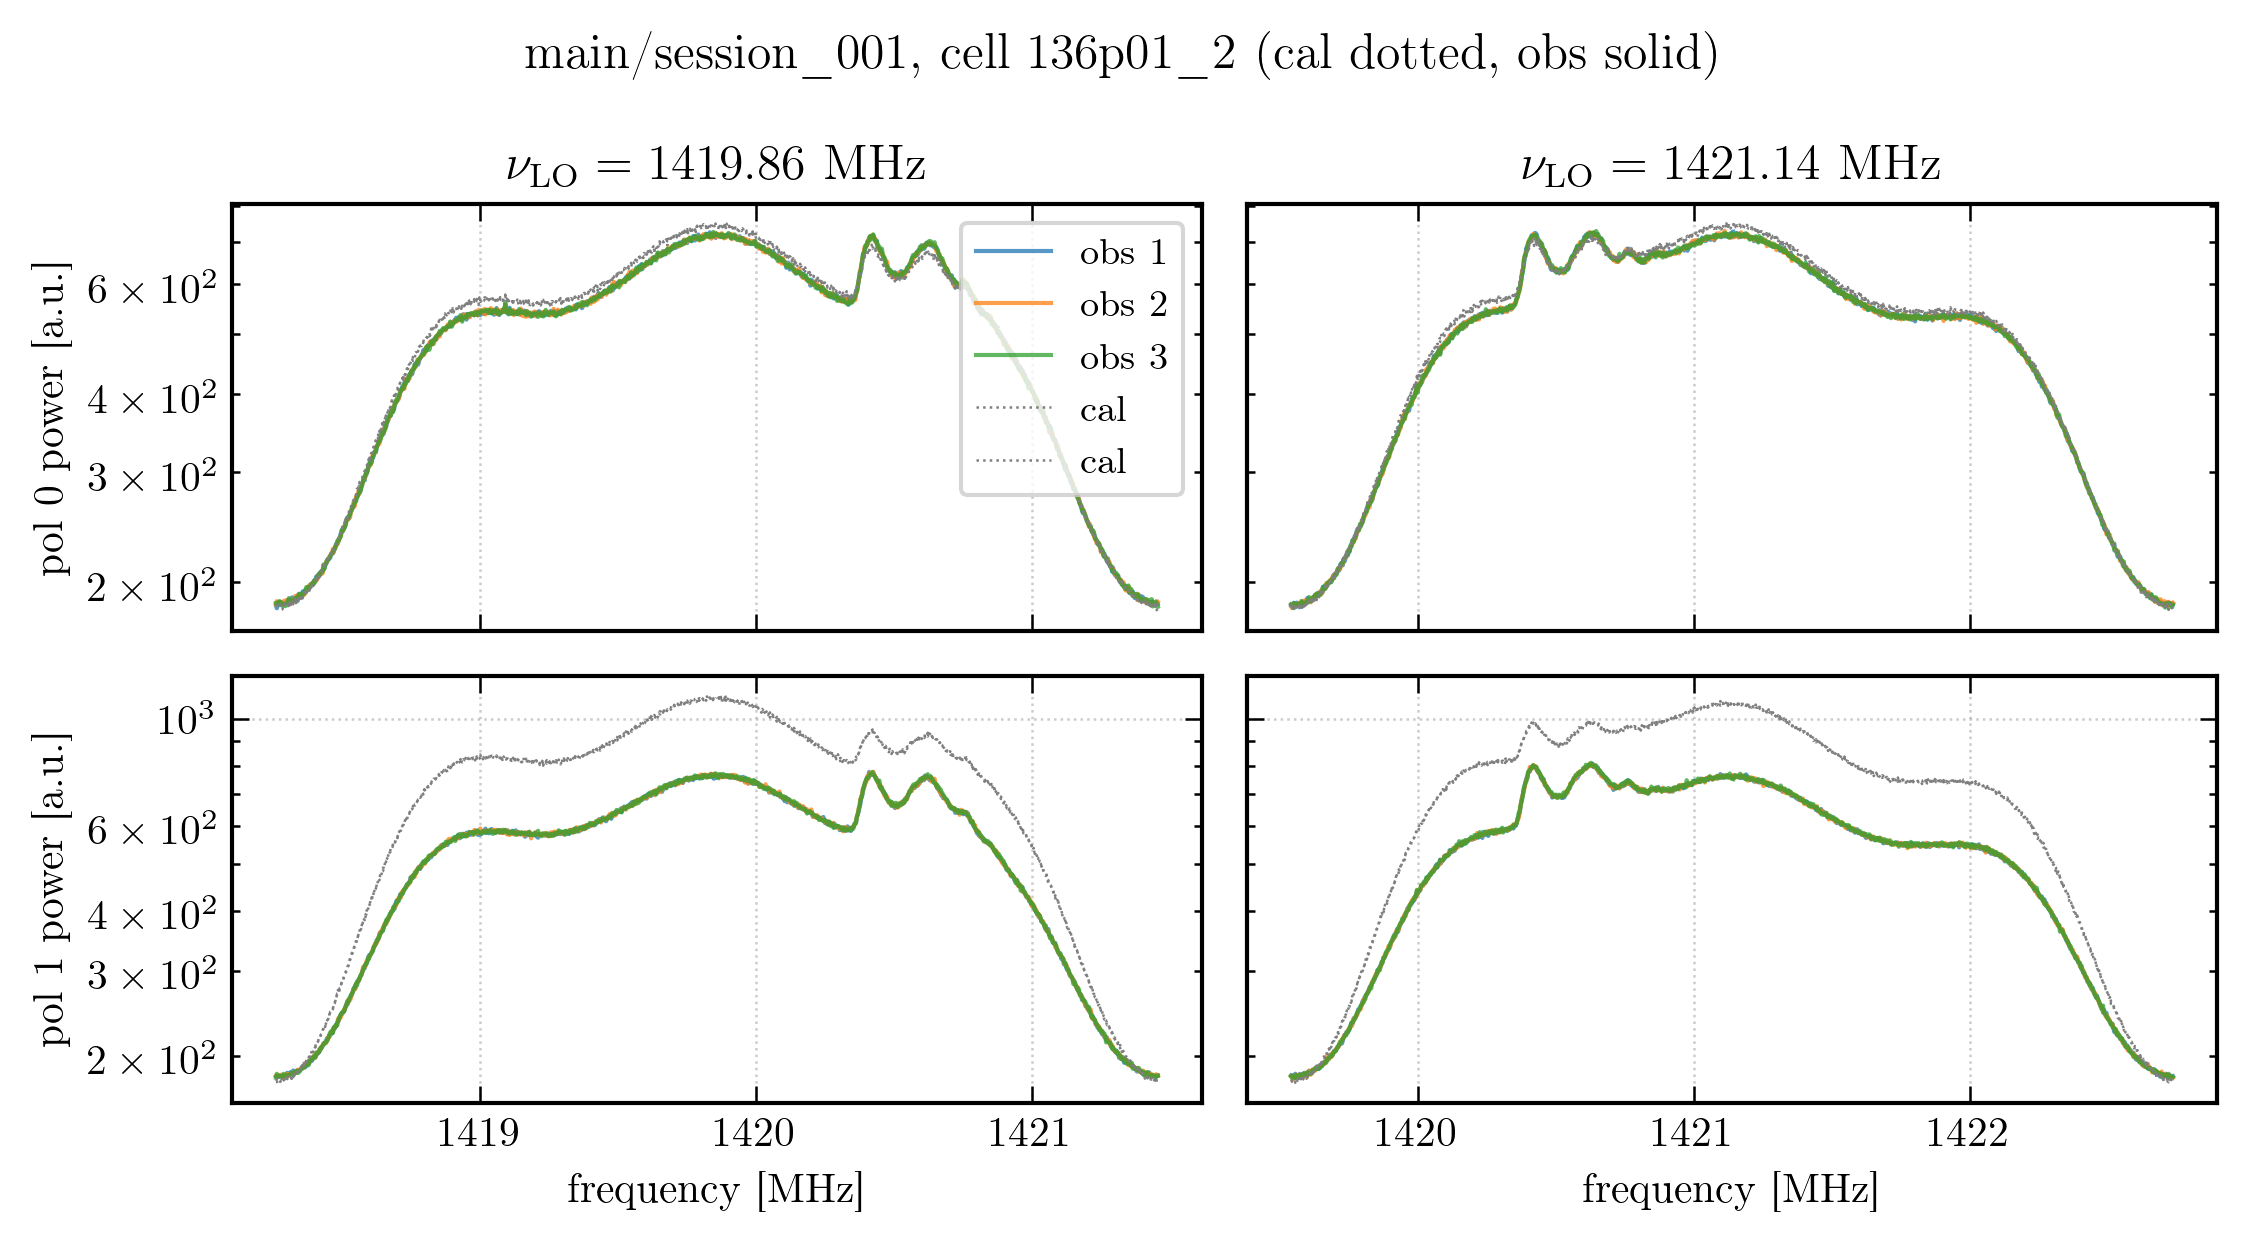

Session: main/session_002, cell: 156p00_0
  obs dumps: 6, cal dumps: 4, LOs: [1419.86, 1421.14]


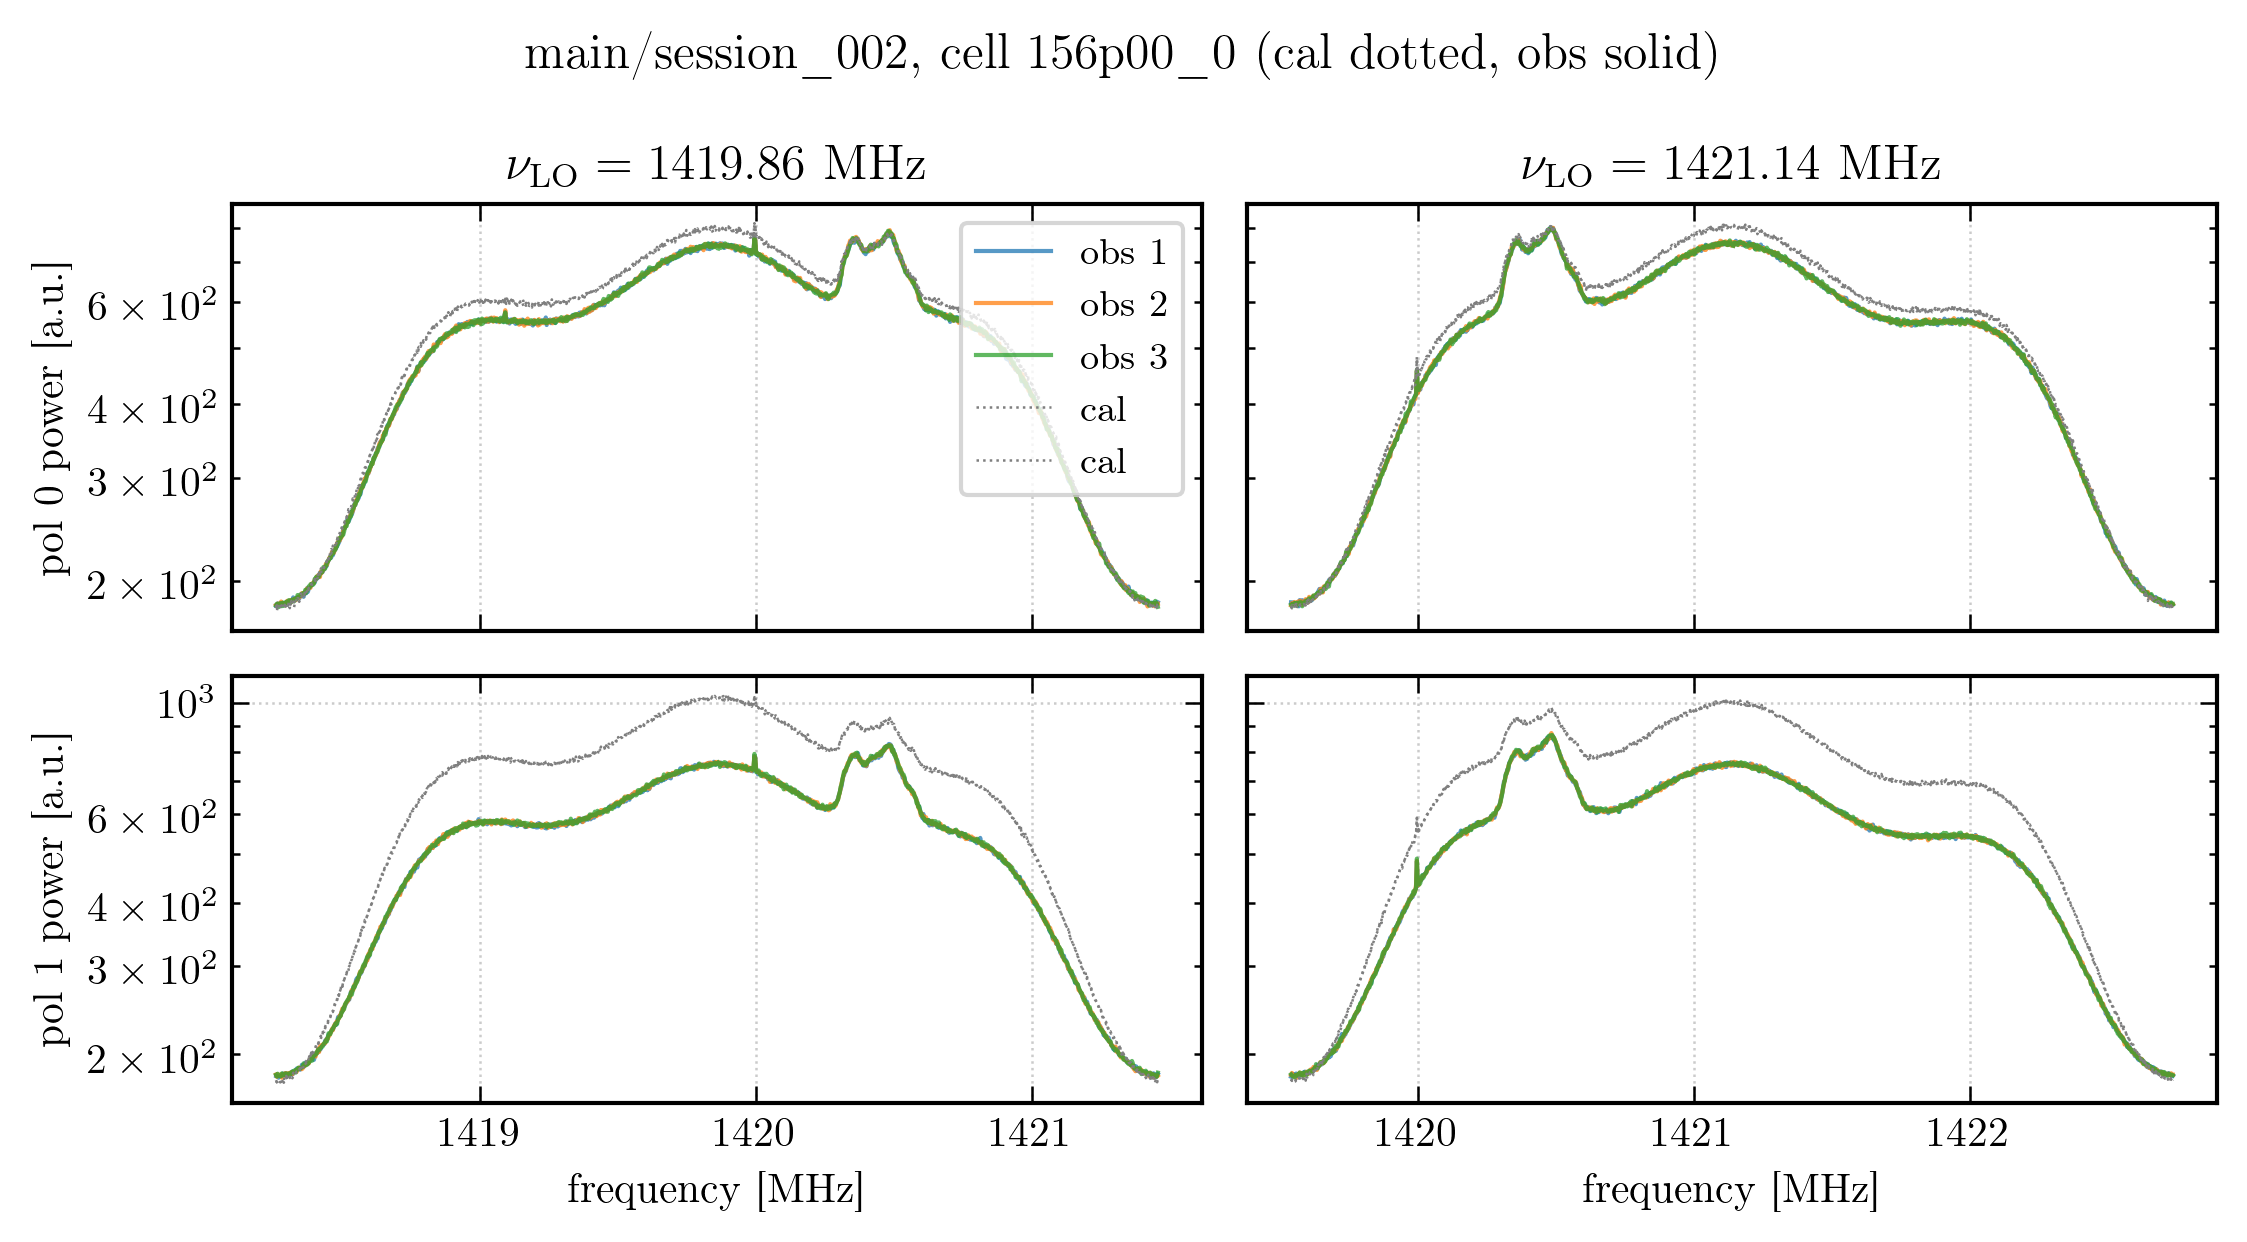

In [5]:
import glob
import random
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

from ugradiolab import plotting
from ugradiolab.plotting import LW_LIGHT, LW_FINE, ALPHA_STANDARD, NEUTRAL_COLOR

SAMPLE_RATE_MHZ = 3.2
NCHAN = 1024
DC_BIN = NCHAN // 2


def _cell_key(d):
    return Path(d).name.split('_', 1)[1]


def _shift_mask(x):
    x = np.fft.fftshift(x).astype(float)
    x[DC_BIN] = np.nan
    return x


def _load_dumps(cell_dir):
    out = []
    for npz in sorted(glob.glob(f'{cell_dir}/*.npz')):
        d = np.load(npz, allow_pickle=True)
        out.append({
            'corr00': _shift_mask(d['corr00']),
            'corr11': _shift_mask(d['corr11']),
            'lo_freq_mhz': float(d['lo_freq_mhz']),
        })
    return out


candidates_per_session = defaultdict(list)
for data_dir in ('data/main', 'data/nps'):
    for sess in sorted(glob.glob(f'{data_dir}/session_*')):
        obs_dirs = {_cell_key(d): d for d in glob.glob(f'{sess}/obs_*')}
        cal_dirs = {_cell_key(d): d for d in glob.glob(f'{sess}/cal_*')}
        for k in obs_dirs.keys() & cal_dirs.keys():
            candidates_per_session[sess].append((k, obs_dirs[k], cal_dirs[k]))

if not candidates_per_session:
    raise SystemExit('No cells with paired cal+obs found under data/main/ or data/nps/')

f_bb_mhz = np.fft.fftshift(
    np.fft.fftfreq(NCHAN, d=1.0 / (SAMPLE_RATE_MHZ * 1e6))
) / 1e6

pols = [('corr00', r'pol 0'), ('corr11', r'pol 1')]

for sess in sorted(candidates_per_session):
    cell_key, obs_dir, cal_dir = random.choice(candidates_per_session[sess])
    obs_dumps = _load_dumps(obs_dir)
    cal_dumps = _load_dumps(cal_dir)

    los = sorted({d['lo_freq_mhz'] for d in obs_dumps + cal_dumps})
    print(f'Session: {Path(sess).parent.name}/{Path(sess).name}, cell: {cell_key}')
    print(f'  obs dumps: {len(obs_dumps)}, cal dumps: {len(cal_dumps)}, LOs: {los}')

    fig, axes = plt.subplots(
        2, 2,
        figsize=(plotting.TEXTWIDTH_IN, plotting.TEXTWIDTH_IN * 0.55),
        sharex='col', sharey='row',
    )
    for col, lo in enumerate(los):
        f = lo + f_bb_mhz
        obs_lo = [d for d in obs_dumps if abs(d['lo_freq_mhz'] - lo) < 0.05]
        cal_lo = [d for d in cal_dumps if abs(d['lo_freq_mhz'] - lo) < 0.05]
        for row, (key, label) in enumerate(pols):
            ax = axes[row, col]
            for i, d in enumerate(obs_lo):
                ax.plot(f, d[key], lw=LW_LIGHT, alpha=ALPHA_STANDARD,
                        label=f'obs {i+1}' if row == 0 and col == 0 else None)
            for d in cal_lo:
                ax.plot(f, d[key], lw=LW_FINE, ls=':', color=NEUTRAL_COLOR,
                        label='cal' if row == 0 and col == 0 else None)
            ax.set_yscale('log')
            if col == 0:
                ax.set_ylabel(rf'{label} power [a.u.]')
            if row == 1:
                ax.set_xlabel(r'frequency [MHz]')
            if row == 0:
                ax.set_title(rf'$\nu_\mathrm{{LO}} = {lo:.2f}$ MHz')

    axes[0, 0].legend(loc='upper right')
    fig.suptitle(rf'{Path(sess).parent.name}/{Path(sess).name.replace("_", r"\_")}, cell {cell_key.replace("_", r"\_")} (cal dotted, obs solid)')
    fig.tight_layout()
    plt.show()


## Pointing trace in alt/az

Mollweide-style projection of every dump's commanded (az, alt), coloured by UT.  Hard-limit boxes are shaded red: alt outside [`MIN_ALT_DEG`, `MAX_ALT_DEG`] and az outside [`AZ_MIN`, `AZ_MAX`].  Useful for spotting cells that the dish was driven to despite the planner's pre-filter (slew anomalies, alt-encoder offsets, cells observed near the limit).


<>:95: SyntaxWarning: invalid escape sequence '\c'
<>:95: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_119947/2156375154.py:95: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Azimuth (0$^\circ$ = N at centre)')


Loaded 3588 dumps spanning 2026-05-11 09:24 -> 2026-05-11 23:56 UTC


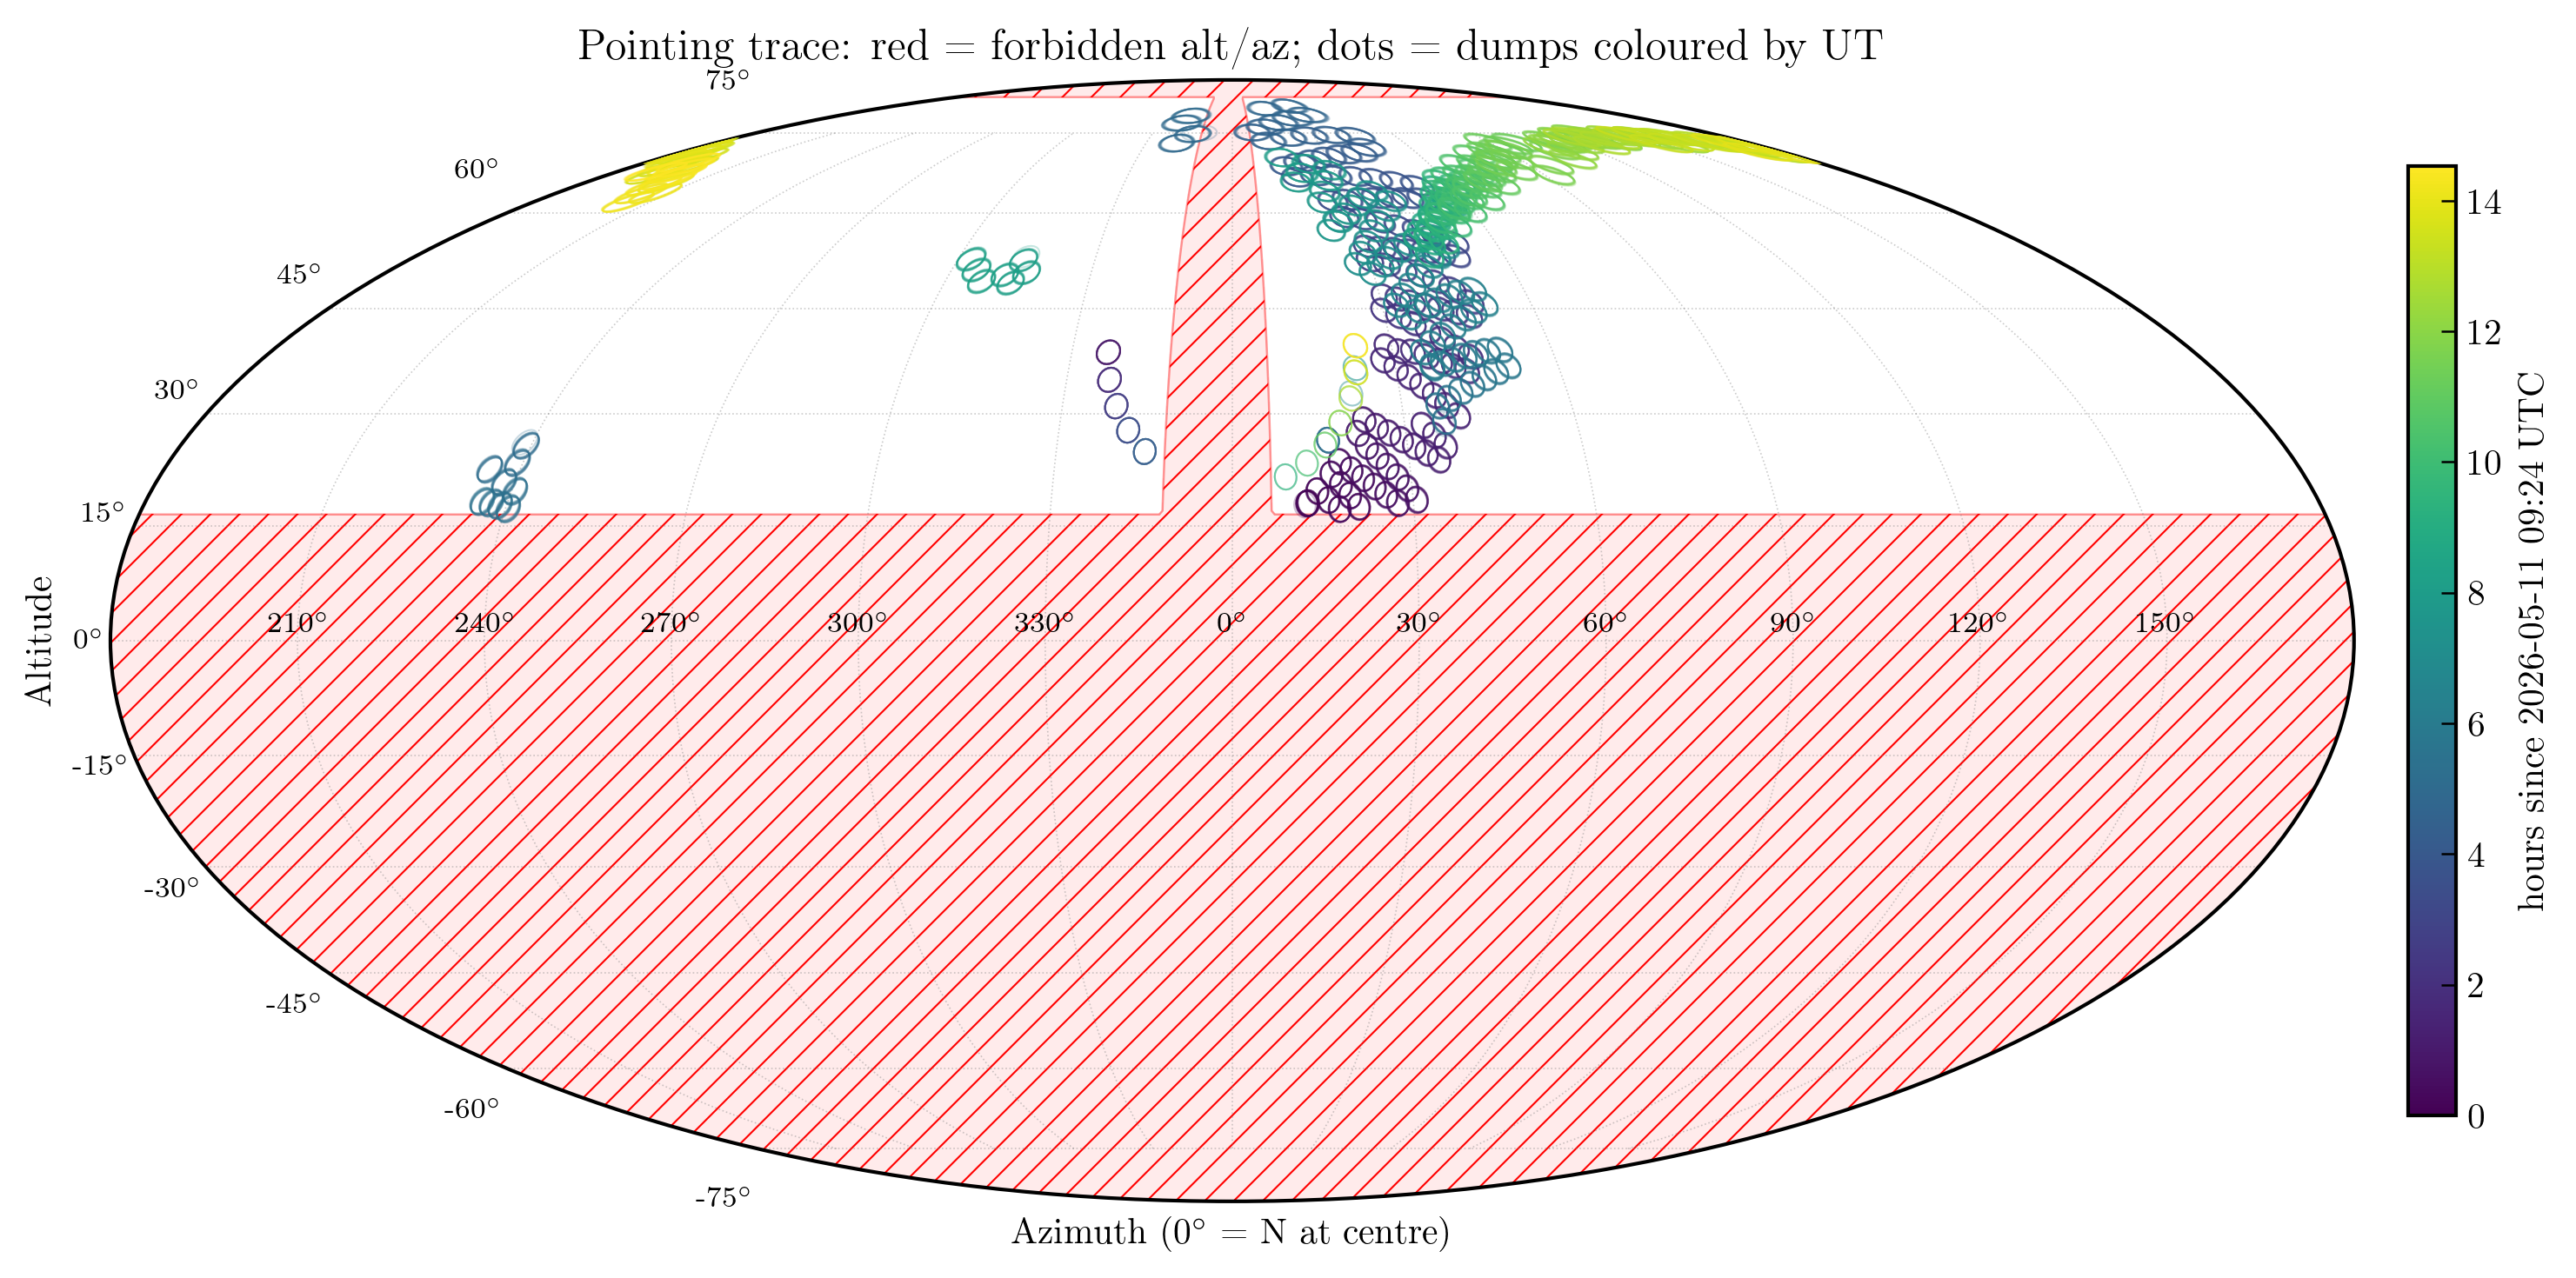

In [6]:
import glob
import datetime as _dt

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


MIN_ALT_DEG, MAX_ALT_DEG = 17.0, 83.0
AZ_MIN_DEG, AZ_MAX_DEG = 7.0, 348.0

records = []
for data_dir in ('data/main', 'data/nps'):
    for npz in sorted(glob.glob(f'{data_dir}/session_*/*_*/*.npz')):
        try:
            with np.load(npz, allow_pickle=False) as f:
                records.append((float(f['time']),
                                float(f['alt_deg']),
                                float(f['az_deg'])))
        except (OSError, KeyError, ValueError):
            continue

if not records:
    raise SystemExit('No dumps found under data/main or data/nps.')

records.sort(key=lambda r: r[0])
ts = np.array([r[0] for r in records])
alt = np.array([r[1] for r in records])
az = np.array([r[2] for r in records])
print(f'Loaded {len(records)} dumps spanning '
      f'{_dt.datetime.fromtimestamp(ts[0], _dt.UTC):%Y-%m-%d %H:%M} -> '
      f'{_dt.datetime.fromtimestamp(ts[-1], _dt.UTC):%Y-%m-%d %H:%M} UTC')

# Centre az=0 (north) on the panel: lon = az if az <= 180 else az - 360.
az_lon = ((az + 180.0) % 360.0) - 180.0
lon = np.deg2rad(az_lon)
lat = np.deg2rad(alt)

fig, _ax = plt.subplots(figsize=(11, 5.5))
_ax.remove()
ax = fig.add_subplot(111, projection='mollweide')
ax.grid(True, lw=0.4, alpha=0.4)

# Forbidden alt/az region as a 1 deg lon/lat mask -> red contourf + hatch,
# matching the styling of the never-observable overlay in the lv notebook.
LON_DENSE = np.linspace(-180, 180, 361)
LAT_DENSE = np.linspace(-90, 90, 181)
L, B = np.meshgrid(LON_DENSE, LAT_DENSE)
az_grid = (L + 360.0) % 360.0  # back to az in [0, 360)
forbidden = (
    (B < MIN_ALT_DEG) | (B > MAX_ALT_DEG)
    | (az_grid < AZ_MIN_DEG) | (az_grid > AZ_MAX_DEG)
)
with mpl.rc_context({'hatch.color': 'red', 'hatch.linewidth': 0.5}):
    ax.contourf(np.deg2rad(L), np.deg2rad(B), forbidden.astype(float),
                levels=[0.5, 1.5], colors=['red'], alpha=0.08,
                hatches=['///'], zorder=0)
    ax.contour(np.deg2rad(L), np.deg2rad(B), forbidden.astype(float),
               levels=[0.5], colors=['red'], linewidths=0.6,
               alpha=0.4, zorder=1)

# Pointing trace, colour-coded by UT.
hours_from_start = (ts - ts[0]) / 3600.0
from matplotlib.collections import PolyCollection
from plotters import beam_outline_polys

HPBW_DEG = 3.4
# Beam outlines as small circles in (az, alt). beam_outline_polys clamps
# the 1/cos(alt) correction near zenith and splits any beam that straddles
# the +/-180 deg seam, so beams pointed near south or near zenith no longer
# render as polygons spanning the entire projection.
polys, src_idx = beam_outline_polys(az_lon, alt, HPBW_DEG)
_norm = mpl.colors.Normalize(hours_from_start.min(),
                              max(hours_from_start.max(), hours_from_start.min() + 1e-6))
_cmap = plt.get_cmap('viridis')
_edge_colors = _cmap(_norm(hours_from_start))[src_idx]
ax.add_collection(PolyCollection(
    polys, facecolors='none', edgecolors=_edge_colors,
    linewidths=0.5, alpha=0.25, zorder=5,
))
_sm = plt.cm.ScalarMappable(norm=_norm, cmap=_cmap)
_sm.set_array([])

cbar = fig.colorbar(_sm, ax=ax, pad=0.02, shrink=0.7)
cbar.set_label(rf'hours since {_dt.datetime.fromtimestamp(ts[0], _dt.UTC):%Y-%m-%d %H:%M} UTC')

# Tick labels: 0 deg = north at centre, sweep clockwise through E/S/W.
tick_lon = np.arange(-150, 180, 30)
tick_az = (tick_lon + 360) % 360
ax.set_xticks(np.deg2rad(tick_lon))
ax.set_xticklabels([rf'{int(a)}$^\circ$' for a in tick_az], fontsize=8)
ax.set_yticklabels([rf'{int(b)}$^\circ$'
                    for b in [-75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75]],
                   fontsize=8)
ax.set_xlabel('Azimuth (0$^\circ$ = N at centre)')
ax.set_ylabel('Altitude')
ax.set_title('Pointing trace: red = forbidden alt/az; dots = dumps coloured by UT')
plt.tight_layout()
plt.show()

## 9. Survey coverage footprint with never-observable shading

Mollweide projection of the cells observed so far (`cell_combined`),
with the never-observable wedge shaded red the same way the Section-8
l-v strip does.  No data are mapped onto the cells -- this is a
coverage/planning view only, complementary to the integrated-intensity
Mollweide above.


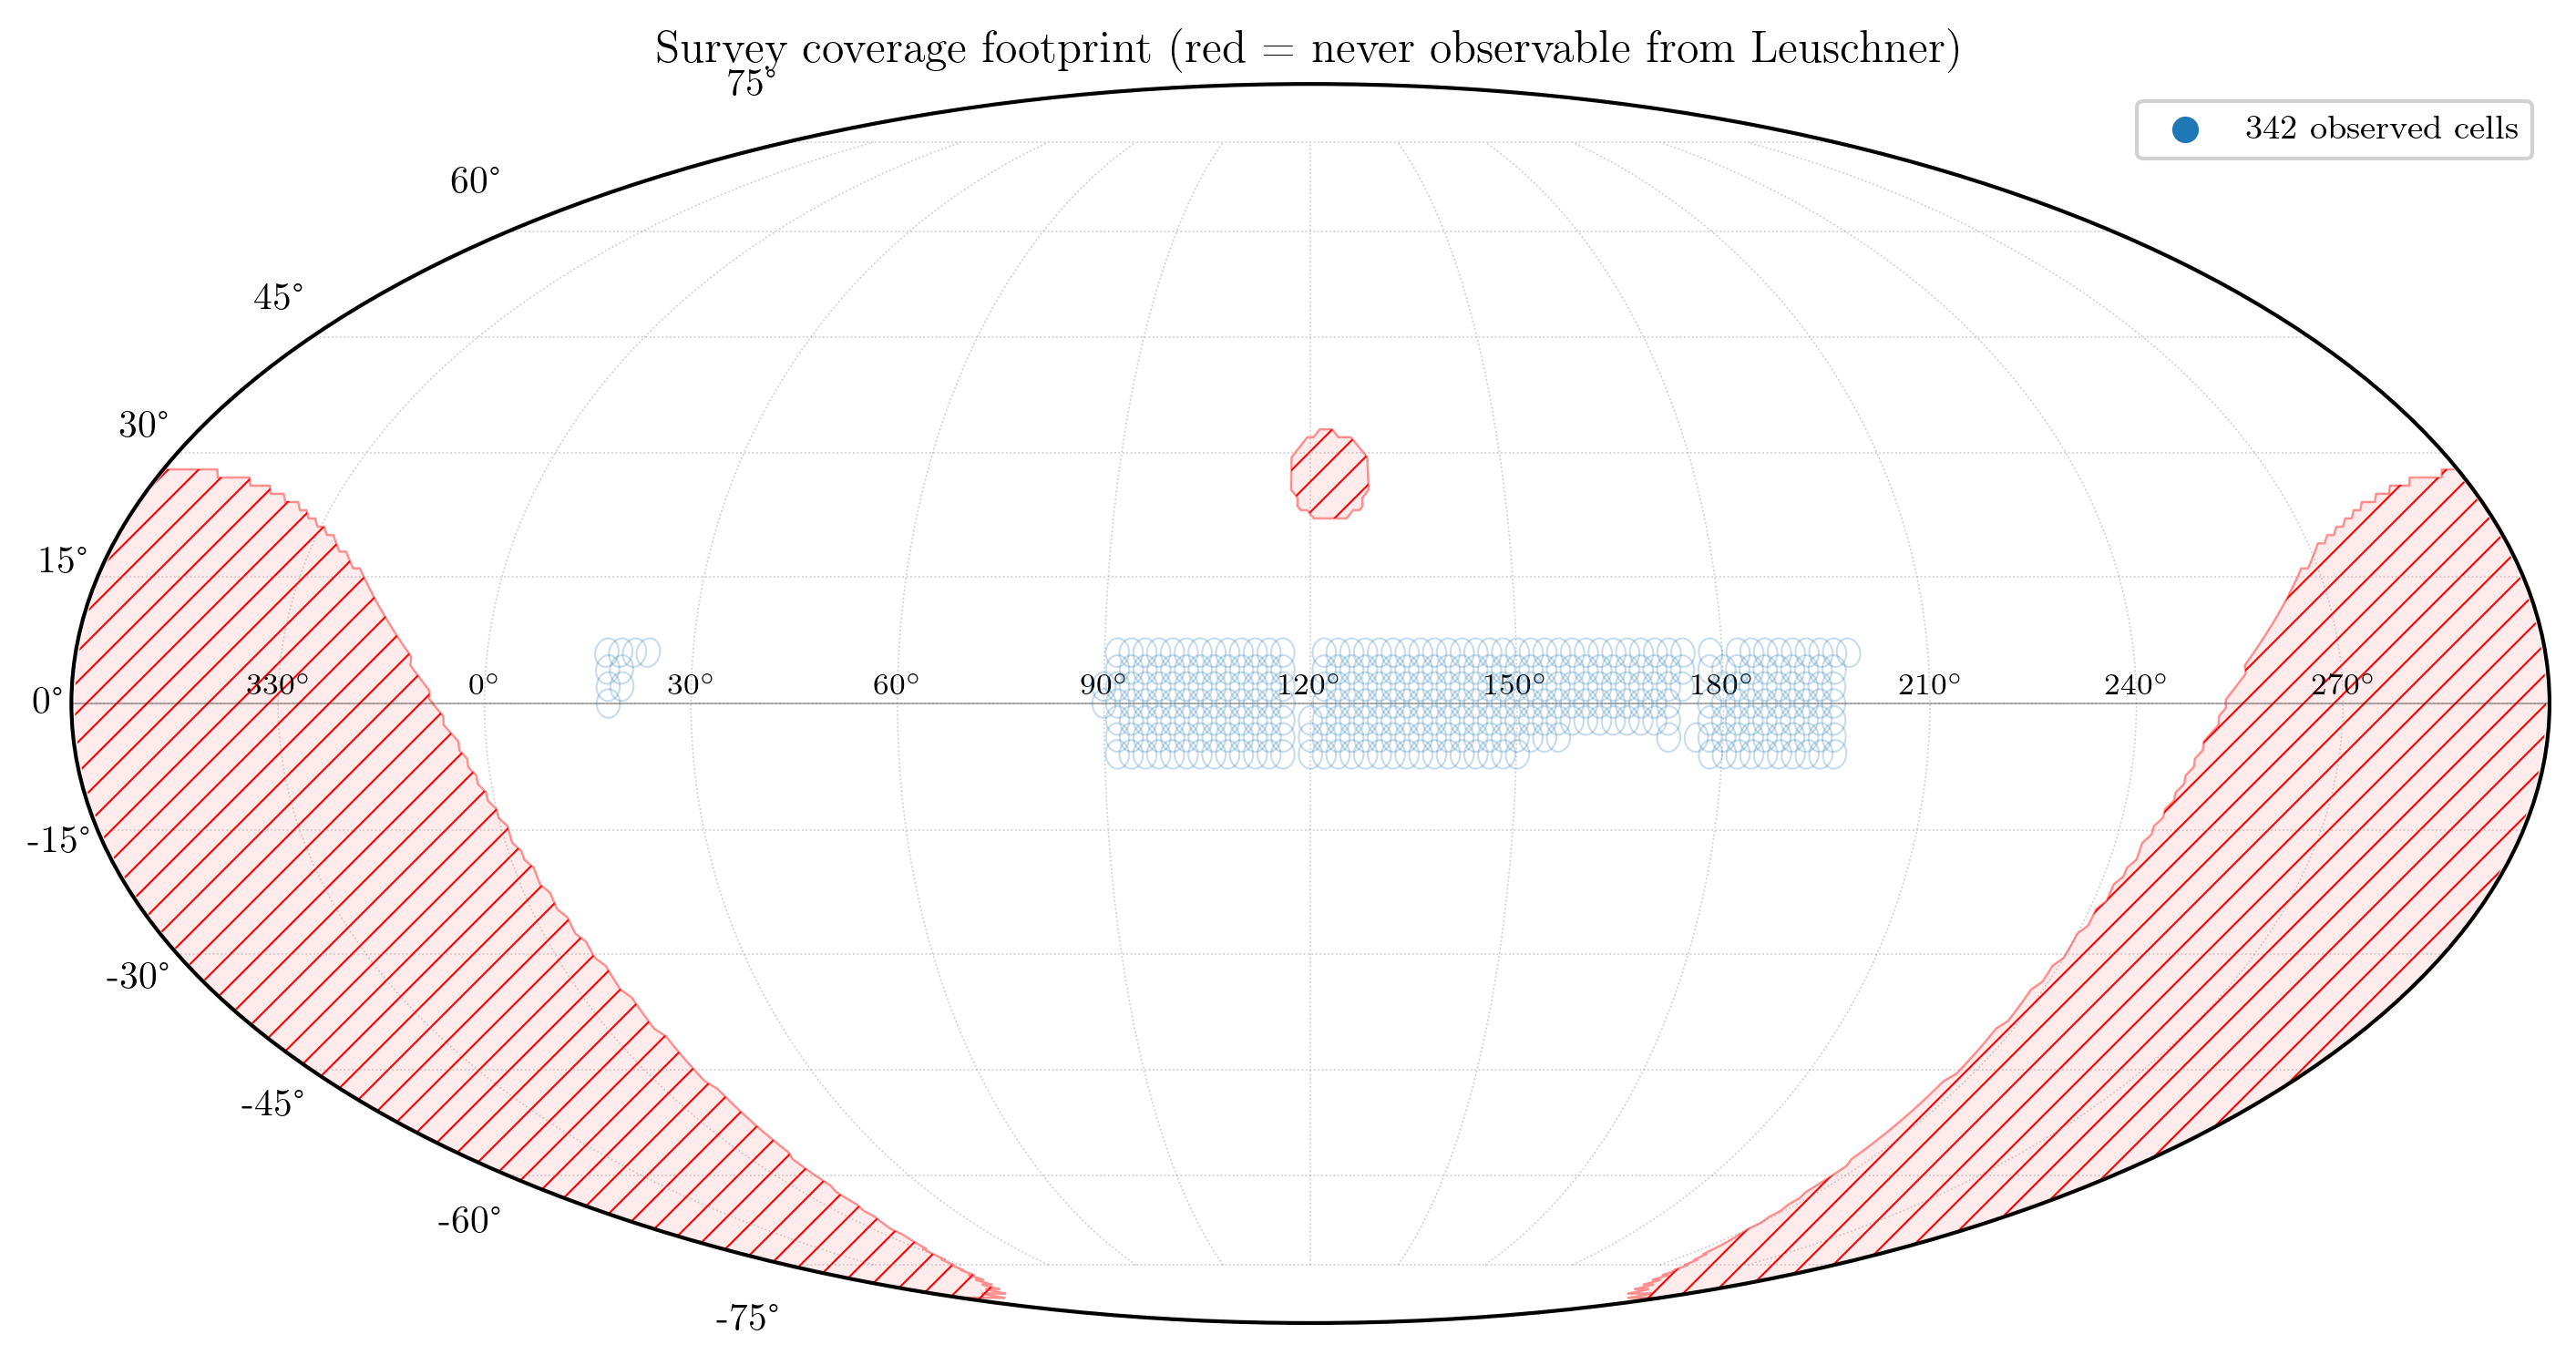

In [7]:
import pickle
from pathlib import Path
if 'cell_combined' not in dir():
    with open(Path('artifacts/scan_load_state.pkl'), 'rb') as _f:
        _state = pickle.load(_f)
    cell_combined = _state['cell_combined']

from plotters import (
    add_never_observable_overlay,
    beam_outline_polys,
    landscapewidth_figure,
)
from ugradiolab.astronomy import LEO_LAT_DEG

MOLL_CENTER_L = 120.0

fig, _ax = landscapewidth_figure(5)
_ax.remove()
ax = fig.add_subplot(111, projection='mollweide')
ax.grid(True, lw=0.4, alpha=0.4)

gl_all = np.array([k[0] for k in cell_combined])
gb_all = np.array([k[1] for k in cell_combined])
gl_shifted = ((gl_all - MOLL_CENTER_L + 180.0) % 360.0) - 180.0

from matplotlib.collections import PolyCollection

HPBW_DEG = 3.4
# Beam outlines as small circles in (l, b). beam_outline_polys clamps the
# cos(b) longitude correction near the poles and splits any beam crossing
# the +/-180 deg seam (after recentering on MOLL_CENTER_L) into two
# polygons, so wrap-around no longer paints cells across the projection.
polys, _src_idx = beam_outline_polys(gl_shifted, gb_all, HPBW_DEG)
ax.add_collection(PolyCollection(
    polys, facecolors='none', edgecolors='C0',
    linewidths=0.5, alpha=0.25, zorder=5,
))
ax.scatter([], [], color='C0', label=f'{len(gl_all)} observed cells')

# Galactic plane reference line
l_line = np.linspace(-np.pi, np.pi, 500)
ax.plot(l_line, np.zeros_like(l_line), lw=0.5, color='k', alpha=0.3, zorder=1)

# Never-observable overlay (same red shading + hatching as Mollweide above)
add_never_observable_overlay(ax, center_l=MOLL_CENTER_L,
                             latitude_deg=LEO_LAT_DEG)

# Re-label longitude ticks in true galactic coords
tick_locs = np.arange(-150, 180, 30)
tick_labels = [rf'{int((t + MOLL_CENTER_L) % 360)}$^\circ$' for t in tick_locs]
ax.set_xticks(np.deg2rad(tick_locs))
ax.set_xticklabels(tick_labels, fontsize=8)

ax.set_title('Survey coverage footprint  (red = never observable from Leuschner)')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

## T_sys vs altitude per session

For each session, plot per-cell `T_sys` against the mean altitude of that
cell's obs dumps. Low altitudes pick up warm ground in the sidelobes, so
an upward trend toward `MIN_ALT_DEG = 17` deg indicates spillover-driven
T_sys rather than a sky-temperature or receiver effect.


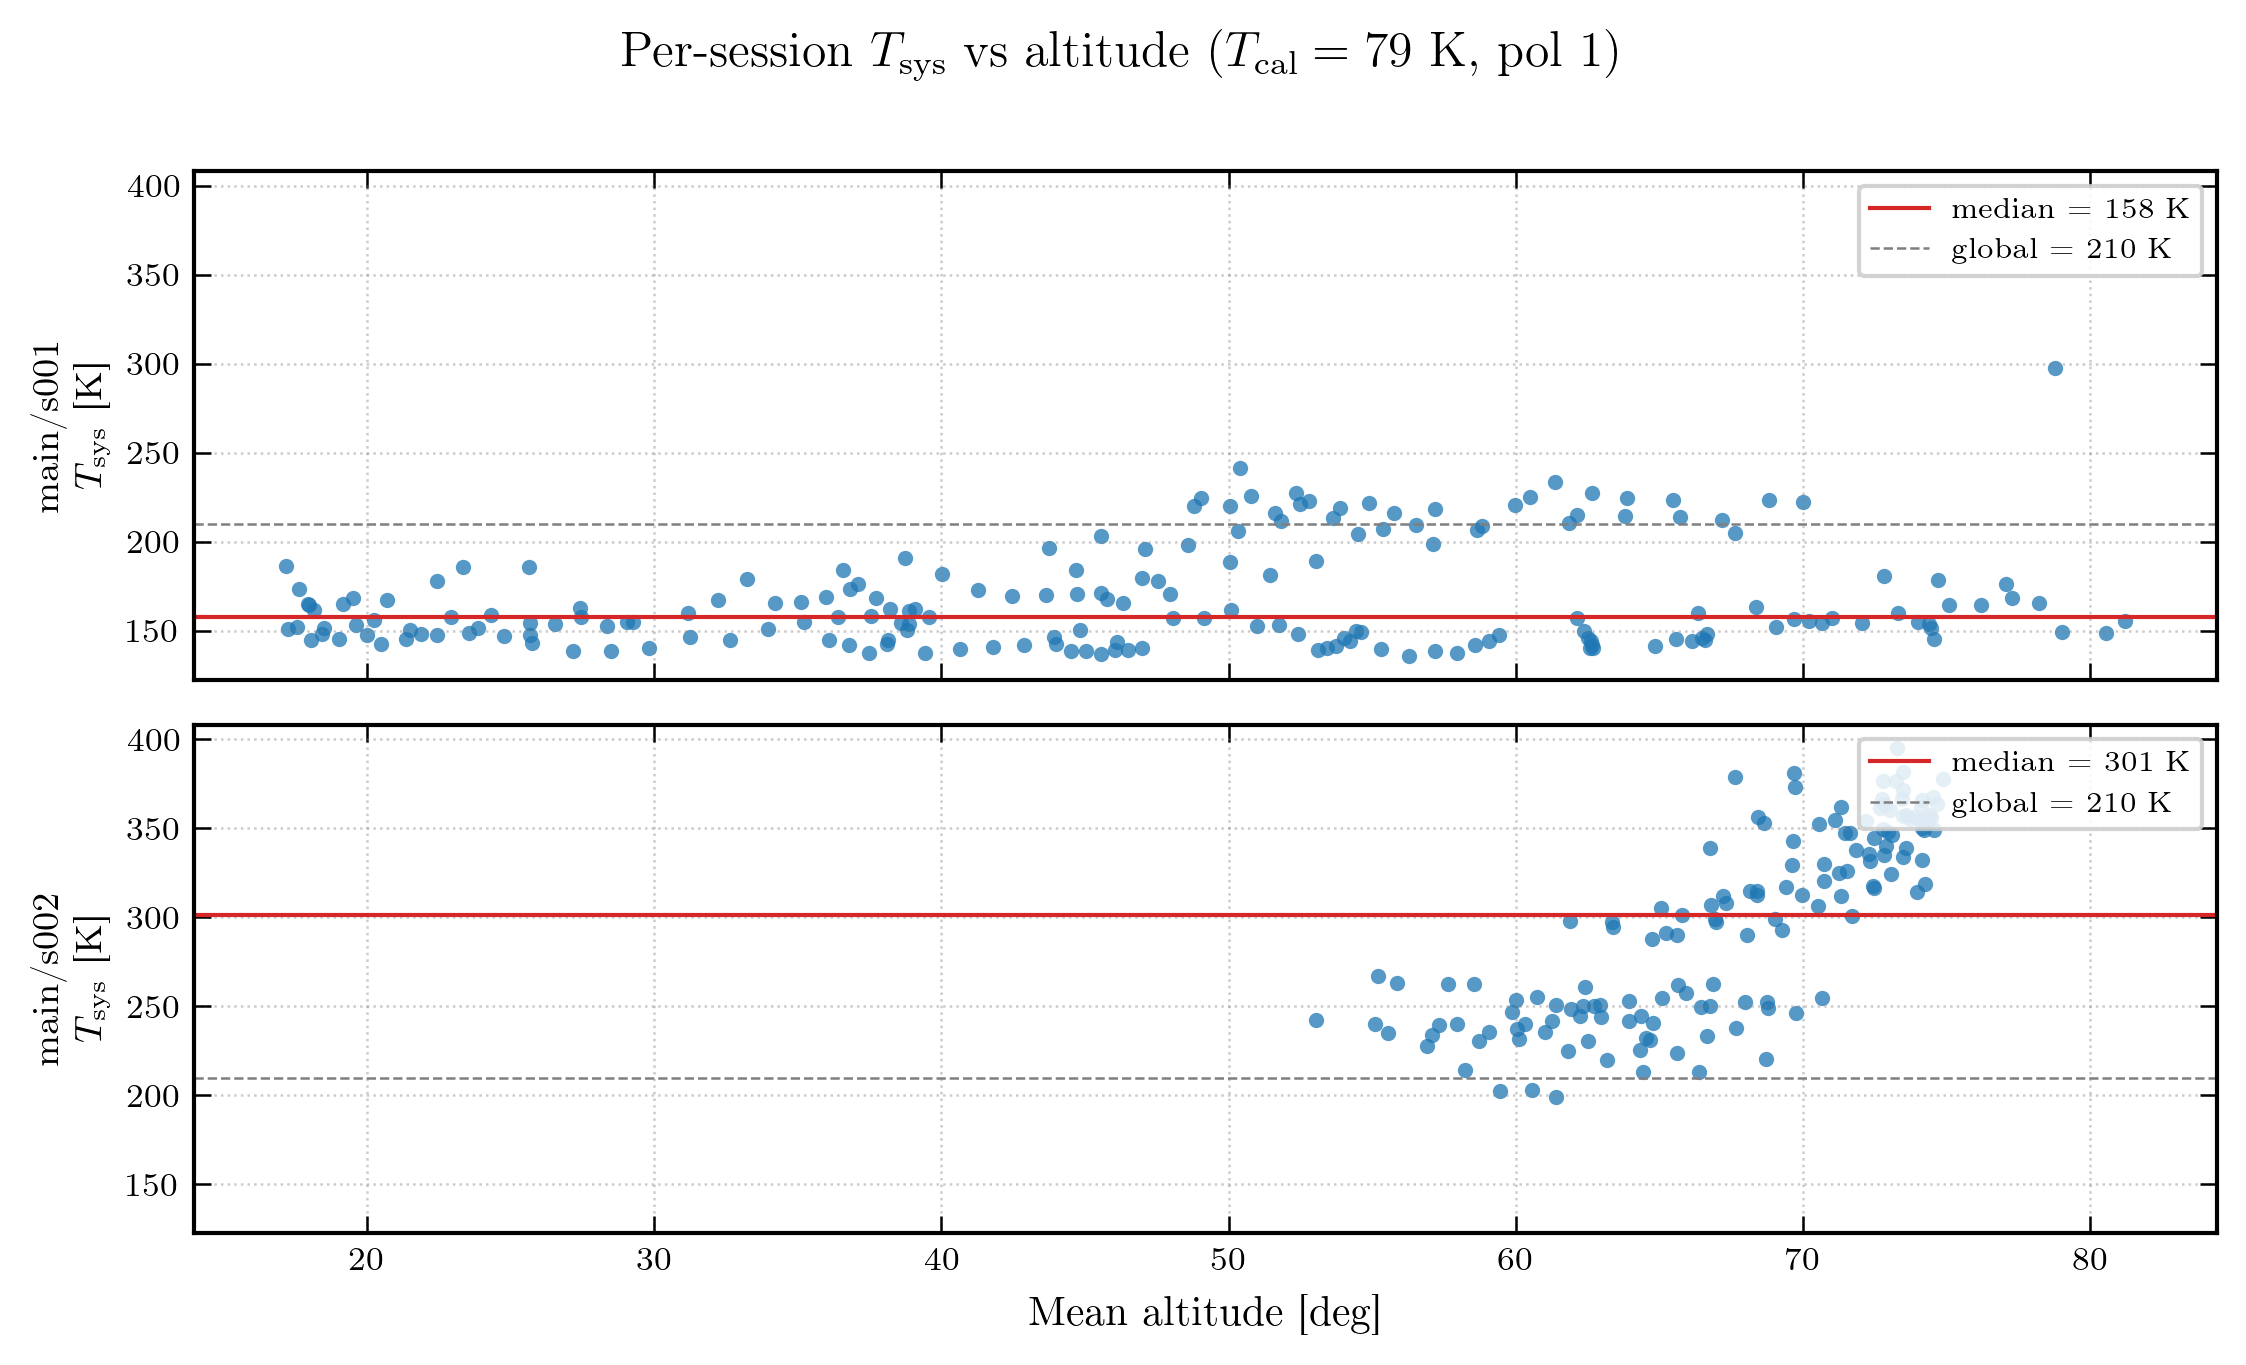

In [8]:
import glob
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from plotters import plot_tsys_vs_alt_per_session


def _parse_coord(s):
    return float(s.replace('p', '.'))


# Mean obs altitude per (session, gl, gb).
alt_by_session_cell = defaultdict(list)
for data_dir in ('data/main', 'data/nps'):
    for npz in sorted(glob.glob(f'{data_dir}/session_*/obs_*/*.npz')):
        p = Path(npz)
        sess = f'{p.parent.parent.parent.name}/{p.parent.parent.name}'
        parts = p.parent.name.split('_')
        try:
            gl, gb = _parse_coord(parts[1]), _parse_coord(parts[2])
        except (IndexError, ValueError):
            continue
        try:
            with np.load(npz, allow_pickle=False) as f:
                alt_by_session_cell[(sess, gl, gb)].append(float(f['alt_deg']))
        except (OSError, KeyError, ValueError):
            continue

alt_points_per_session = defaultdict(lambda: ([], []))
n_missing = 0
for sess in sessions:
    if not tsys_per_session.get(sess):
        continue
    for (s, gl, gb), tsys in tsys_by_session_cell.items():
        if s != sess:
            continue
        alts = alt_by_session_cell.get((sess, gl, gb))
        if not alts:
            n_missing += 1
            continue
        alt_points_per_session[sess][0].append(float(np.mean(alts)))
        alt_points_per_session[sess][1].append(tsys)

if n_missing:
    print(f'{n_missing} (session, cell) entries had no matching npz altitudes')

fig, _ = plot_tsys_vs_alt_per_session(
    dict(alt_points_per_session), T_cal=T_CAL,
)
plt.show()


## Repeat-cell cross-session drift (T_cal diagnostic)

For cells observed in >= 2 sessions, plot per-cell `T_sys` and the diode
step `gain * T_cal` (K-equivalent of `P_on - P_off`) across sessions. Sky
is fixed at the same pointing, so any common across-cells trend isolates
the instrument: a coherent vertical shift between sessions = receiver or
diode drift; an isolated cell moving alone = sky / spillover at that
pointing.


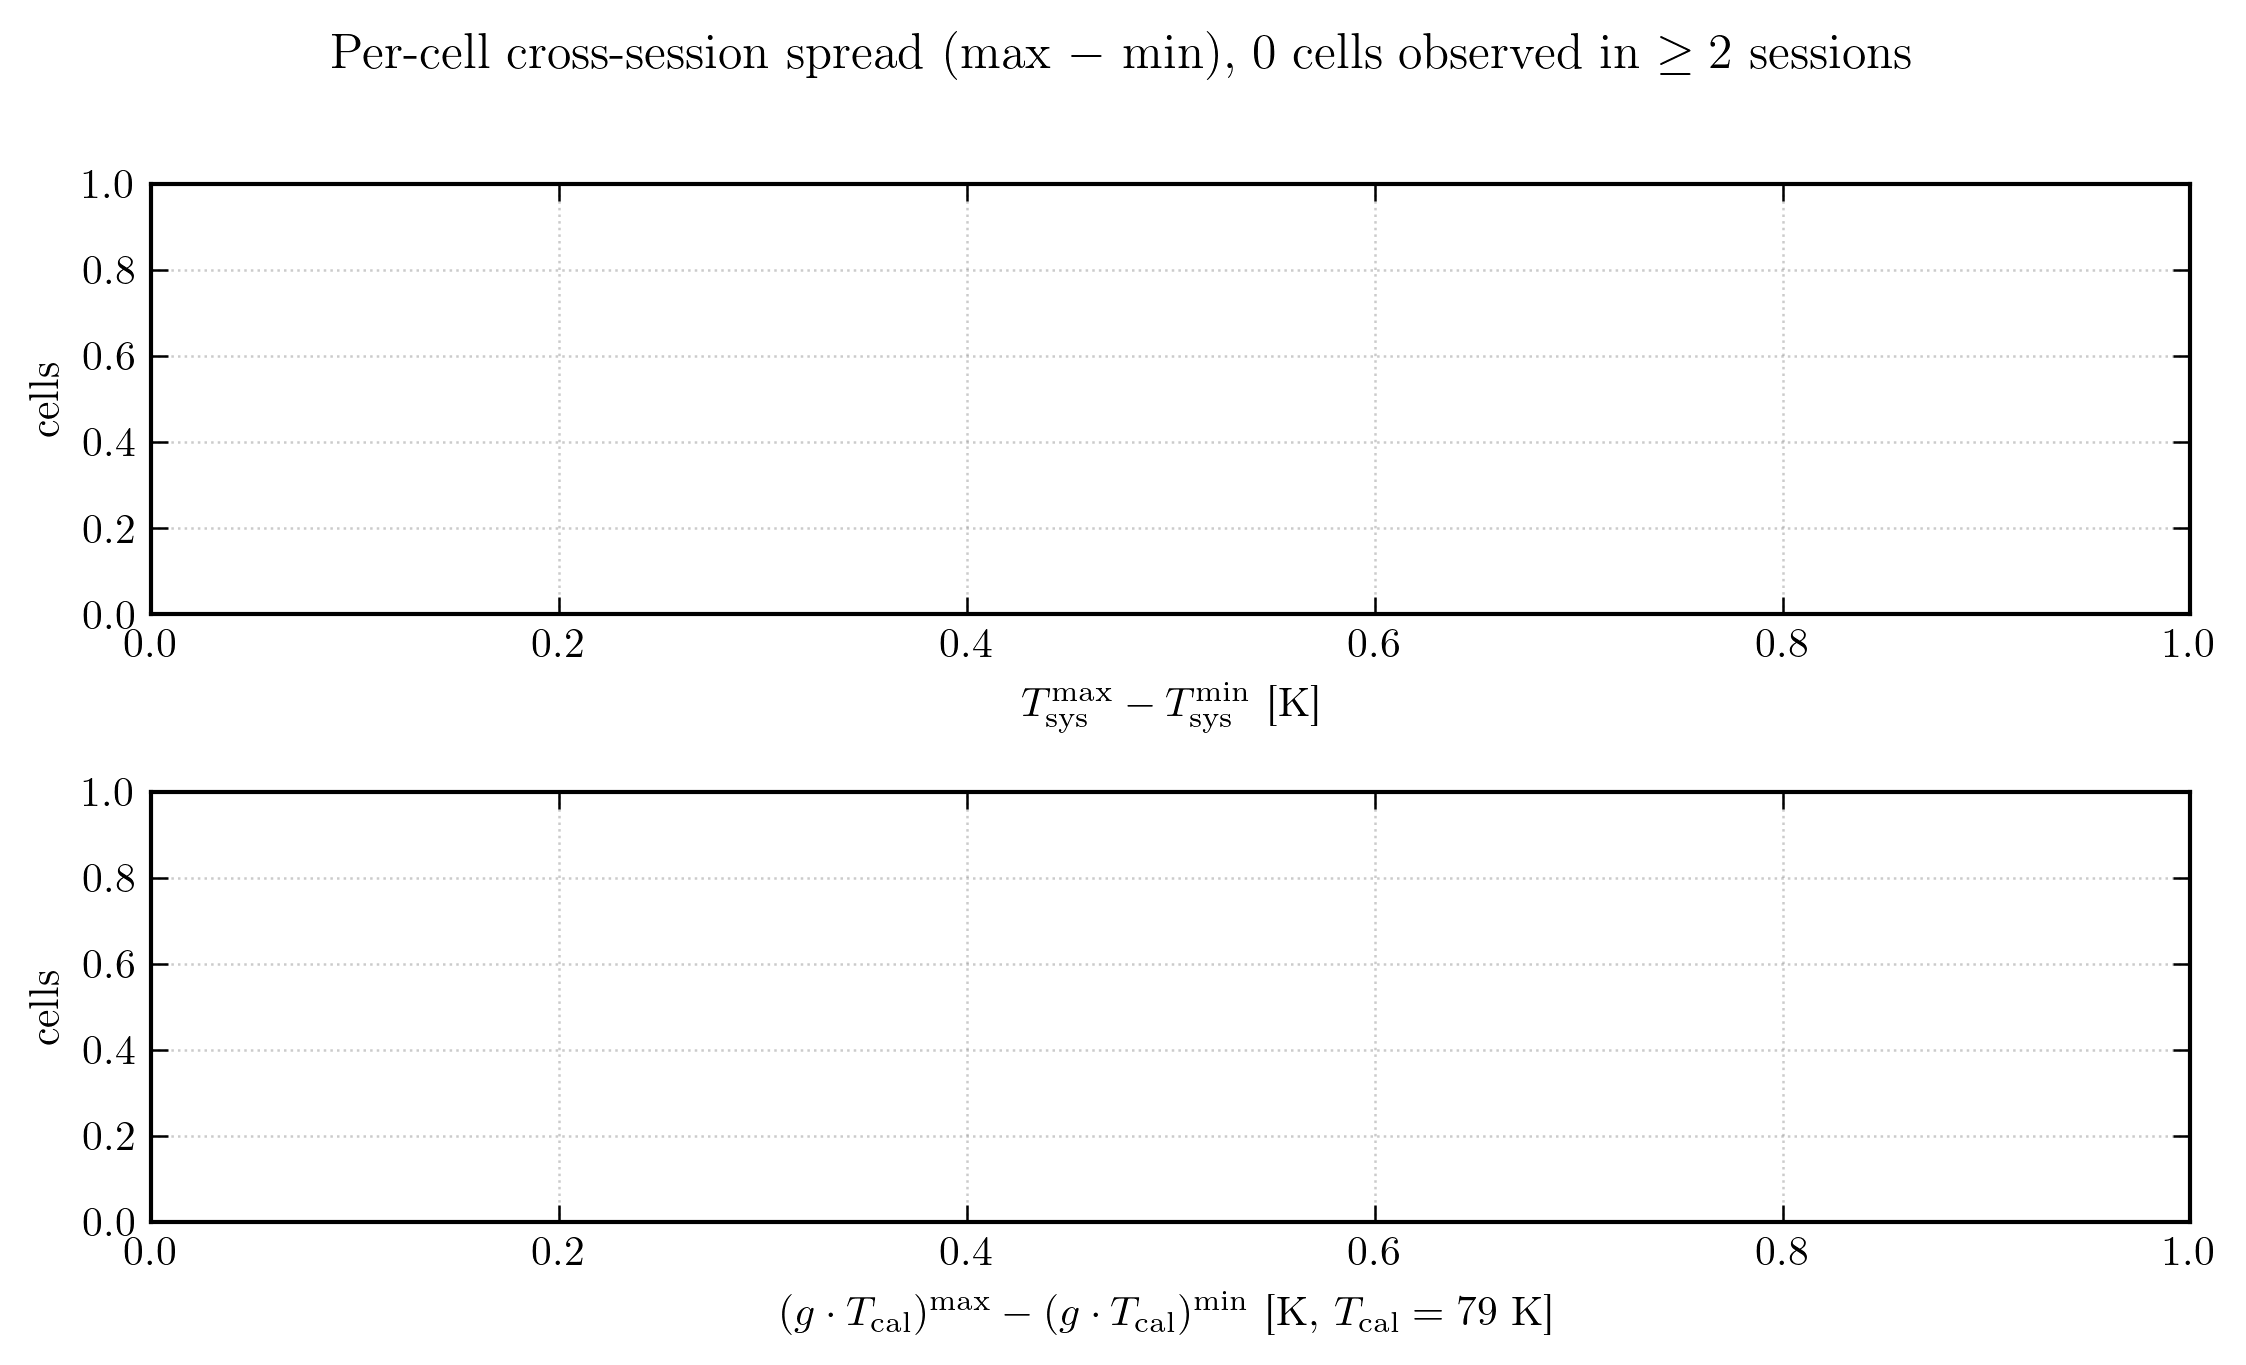

In [9]:
from plotters import plot_repeat_cell_drift

gain_by_session_cell = state['gain_by_session_cell']

# Order sessions chronologically using the earliest obs timestamp we have per session.
def _session_t0(sess):
    ts_all = []
    for (s, gl, gb), ts_list in ts_by_session_cell.items():
        if s == sess and ts_list:
            ts_all.append(min(ts_list))
    return min(ts_all) if ts_all else float('inf')


sessions_ordered = sorted(
    {s for (s, _, _) in tsys_by_session_cell.keys()},
    key=_session_t0,
)

fig, _ = plot_repeat_cell_drift(
    sessions_ordered, tsys_by_session_cell, gain_by_session_cell,
    T_cal=T_CAL,
)
plt.show()


## Recal drift timeline

Per-visit T_sys and diode step (g * T_cal) at the fixed circumpolar recal
target (and its backup) across each session. Identical sky at every visit,
so any drift here is purely instrumental. Sessions without recal data
(legacy 001-006) are skipped automatically.

The primary (`recal_drift`) and backup (`recal_drift_bk`) traces should
share the same shape but sit at different absolute T_sys (different sky
brightness at each pointing). Agreement on the shape validates that the
drift is receiver / diode rather than something local to one corner of
the sky.


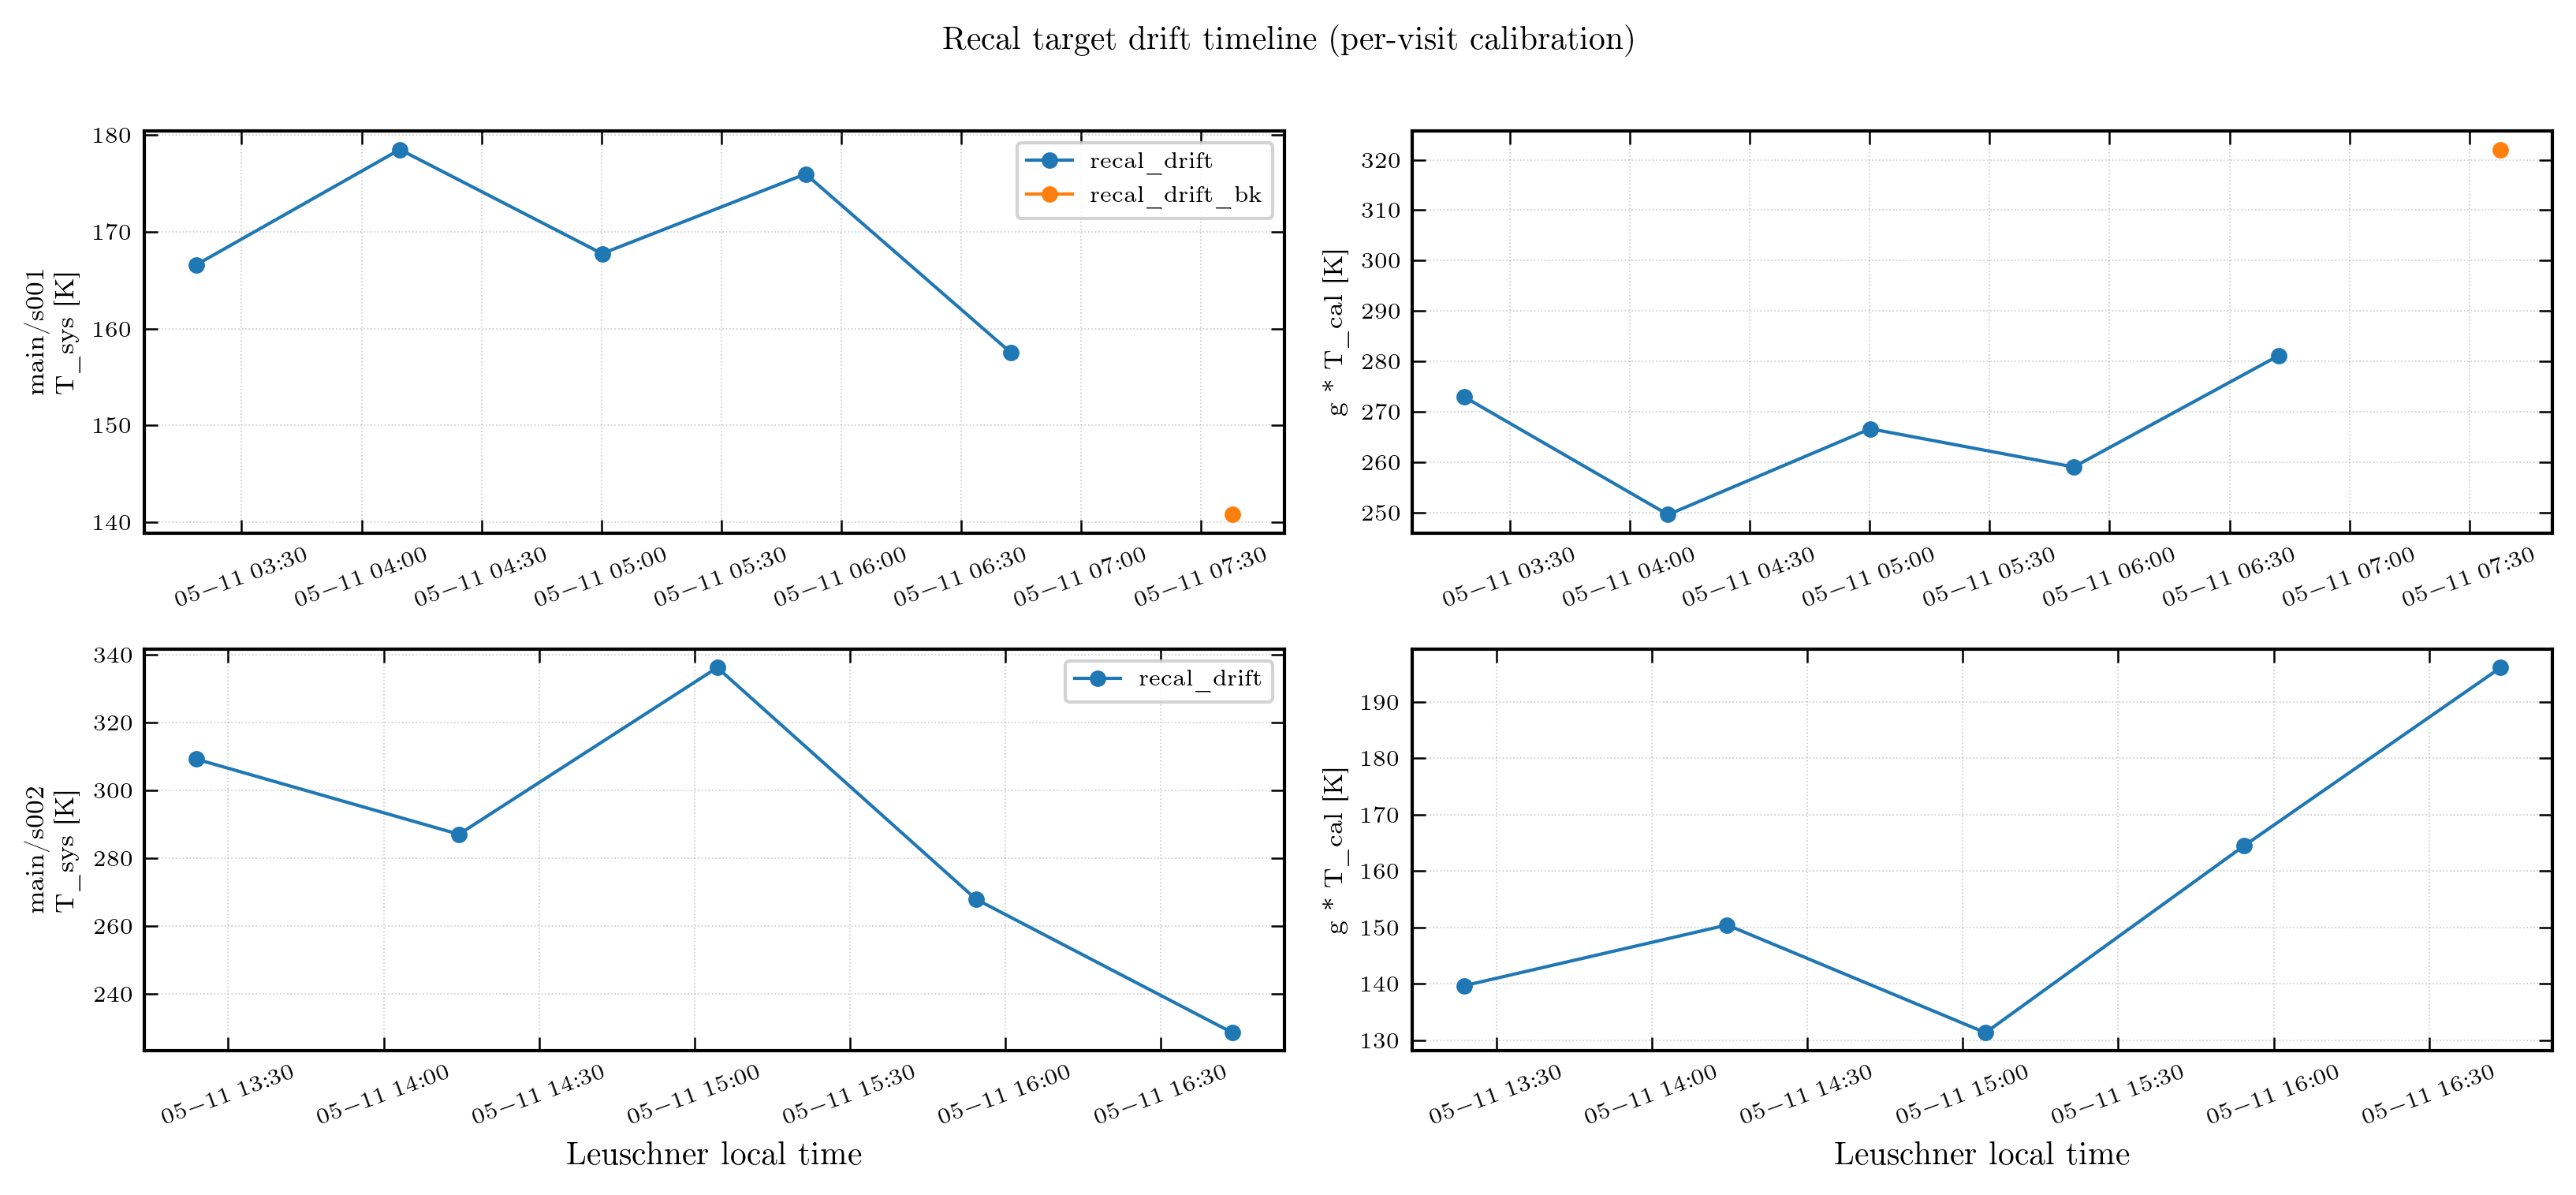

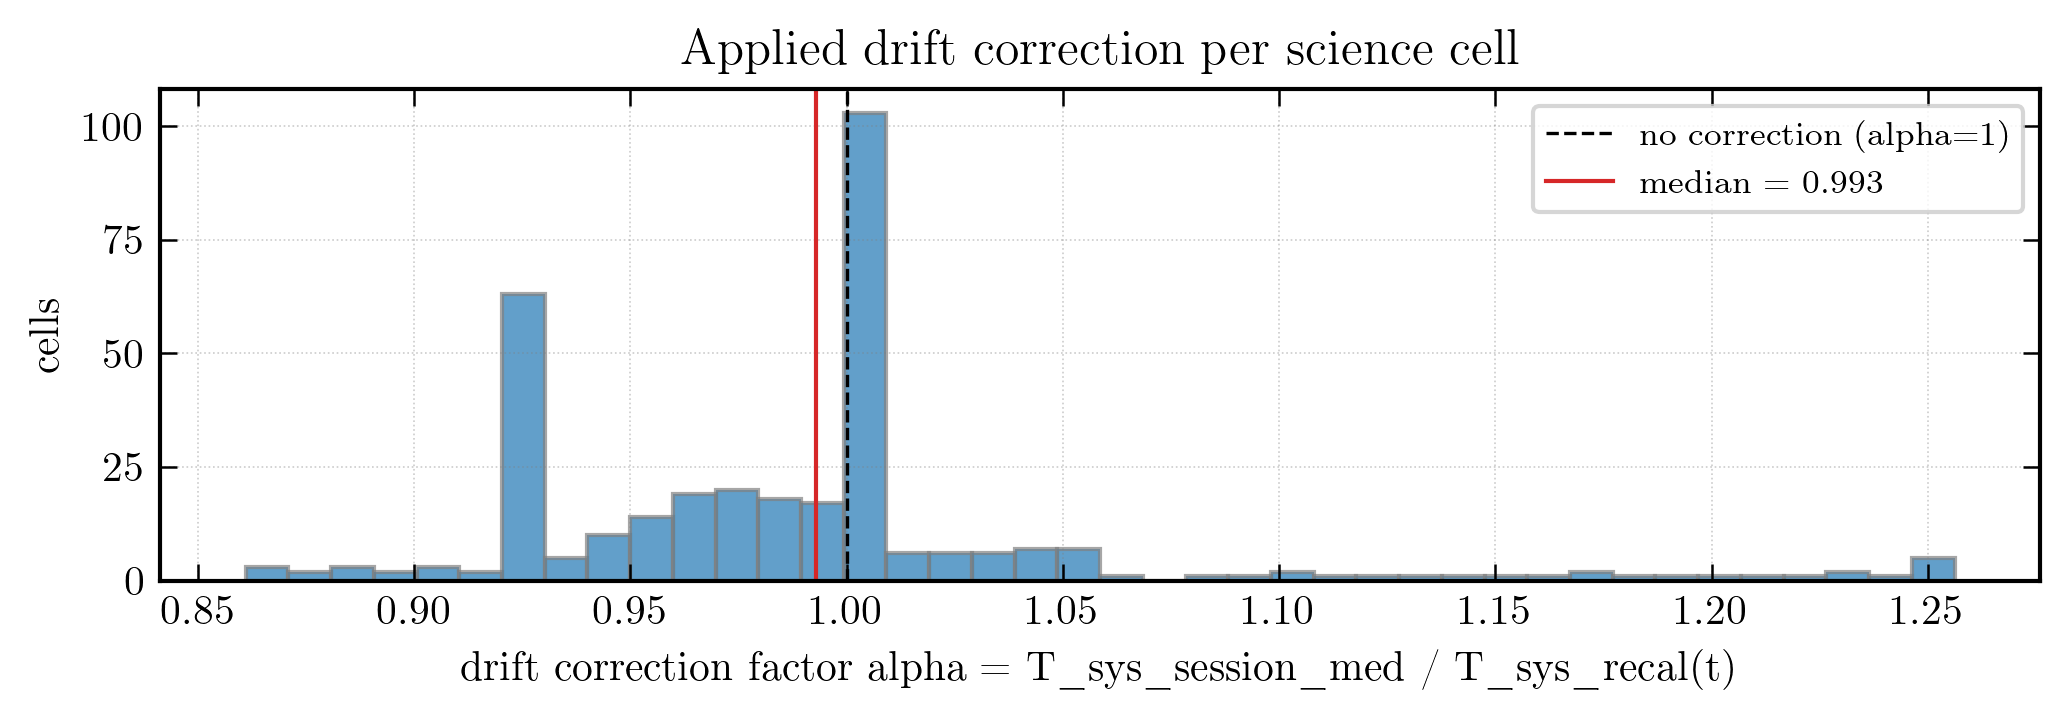

In [10]:
import datetime as _dt
from collections import defaultdict
from zoneinfo import ZoneInfo

import matplotlib.dates as mdates

LEO_TZ_RECAL = ZoneInfo('America/Los_Angeles')

# Pull the per-visit recal timeline from the state pickle (written by
# main_scan_load.ipynb Section 5b).
recal_visits = state.get('recal_visits', {})
drift_alpha_by_sc = state.get('drift_alpha_by_session_cell', {})

if not recal_visits:
    print('No recal visits found in state pickle. '
          'Legacy sessions (001-006) had no recal target; '
          'take a recal-instrumented session to populate this panel.')
else:
    # Group visits per session, keep target id separate so the two targets
    # plot as different traces.
    by_session = defaultdict(lambda: defaultdict(list))
    for key, visits in recal_visits.items():
        sess, tgt = key.split('||', 1)
        for v in visits:
            by_session[sess][tgt].append(v)

    n_sessions = len(by_session)
    fig, axes = plt.subplots(
        n_sessions, 2,
        figsize=(11, 2.0 * n_sessions + 1.0),
        sharex='row', squeeze=False,
    )
    sessions_chrono = sorted(
        by_session.keys(),
        key=lambda s: min(v['t_mid'] for vs in by_session[s].values() for v in vs),
    )

    for row, sess in enumerate(sessions_chrono):
        ax_t = axes[row, 0]
        ax_g = axes[row, 1]
        target_data = by_session[sess]
        all_t_mid_session = []
        for tgt, visits in sorted(target_data.items()):
            ts = np.array([v['t_mid'] for v in visits])
            order = np.argsort(ts)
            ts = ts[order]
            T_sys = np.array([v['T_sys'] for v in visits])[order]
            g_T = np.array([v['g_T_cal'] for v in visits])[order]
            t_local = [_dt.datetime.fromtimestamp(t, LEO_TZ_RECAL) for t in ts]
            all_t_mid_session.extend(t_local)
            ax_t.plot(t_local, T_sys, '-o', ms=4, lw=1.0, label=tgt)
            ax_g.plot(t_local, g_T, '-o', ms=4, lw=1.0, label=tgt)
        ax_t.set_ylabel(f'{sess.replace("session_", "s")}\nT_sys [K]', fontsize=8)
        ax_g.set_ylabel('g * T_cal [K]', fontsize=8)
        ax_t.grid(True, lw=0.4, alpha=0.4)
        ax_g.grid(True, lw=0.4, alpha=0.4)
        ax_t.legend(loc='best', fontsize=7, framealpha=0.85)
        for ax in (ax_t, ax_g):
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M', tz=LEO_TZ_RECAL))
            ax.tick_params(axis='x', rotation=20, labelsize=7)
            ax.tick_params(axis='y', labelsize=7)

    axes[-1, 0].set_xlabel('Leuschner local time')
    axes[-1, 1].set_xlabel('Leuschner local time')
    fig.suptitle('Recal target drift timeline (per-visit calibration)', fontsize=10, y=1.0)
    fig.tight_layout()
    plt.show()


# Also: histogram of applied alpha factors across science cells.
alphas = np.array([a for a in drift_alpha_by_sc.values()
                   if np.isfinite(a) and a > 0])
if alphas.size and not np.allclose(alphas, 1.0):
    fig, ax = plt.subplots(figsize=(7, 2.5))
    ax.hist(alphas, bins=40, color='C0', alpha=0.7, edgecolor='gray')
    ax.axvline(1.0, color='k', lw=0.8, ls='--', label='no correction (alpha=1)')
    ax.axvline(float(np.median(alphas)), color='C3', lw=1.0,
               label=f'median = {np.median(alphas):.3f}')
    ax.set_xlabel('drift correction factor alpha = T_sys_session_med / T_sys_recal(t)')
    ax.set_ylabel('cells')
    ax.set_title('Applied drift correction per science cell')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.4)
    fig.tight_layout()
    plt.show()
else:
    print('All alpha factors == 1 (no recal data or insufficient visits to fit drift).')